In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount = True)
import os
root_path = 'gdrive/MyDrive/Cost to Go/Learn Heuristic/Second-Order/LG/'
os.chdir(root_path)

Mounted at /content/gdrive


In [ ]:
%load_ext autoreload
%autoreload 2

### Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, RandomSampler, SequentialSampler, random_split, DataLoader, IterableDataset, ConcatDataset
import numpy as np
import pandas as pd
import json
import random
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import pickle
import copy
import matplotlib.pyplot as plt 
from skimage.morphology import skeletonize, binary_closing
RANDOM_SEED = 42
torchscript_path = '../../../Learn Controller/Second Order Drive/Theta_Deterministic.pt'
actor_model = torch.jit.load(torchscript_path)
actor_model.eval()

def random_seed(seed_value, use_cuda):
    np.random.seed(seed_value)  
    torch.manual_seed(seed_value)  
    random.seed(seed_value)
    if use_cuda:
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)  
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
random_seed(RANDOM_SEED, True)

from Dataset import *
from Tree import *
from Util import *
from Model import *
from Env import *
from mdn import *

### Dataloader Construction

In [ ]:
class LG_Dataset_RRT():
    def __init__(self, trajectories, city = None, batch_size = 1, train = False):
        self.trajectories = trajectories
        self.batch_size = batch_size
        self.train = train
        self.lookahead = 20
        self.highs = np.array([15.0,15.0,np.pi,0.7, 0.7])
        self.lows = -self.highs
        self.city = city
        self.count_dic = {}
        self.c, self.n, self.g = self.process_data()
        print(self.c.shape)
        self.DataLoader = self.get_dataloader(self.c, self.n, self.g)

    def preprocess_state(self, state):
        return np.array([(state[i]-self.lows[i])/(self.highs[i]-self.lows[i]) for i in range(len(state))])

    def decode_state(self, state):
        return np.array([state[i]*(self.highs[i]-self.lows[i])+self.lows[i] for i in range(len(state))])

    def process_data(self):
        curr, next, goal = [], [], []

        for info in (self.trajectories):
            traj, start, _, local_goal = info
            try:
                global_goal = traj[-1]
            except:
                continue
            for s, lg in zip(start, local_goal):
                curr.append(list(s))
                next.append(list(lg))
                goal.append(global_goal)
        
        # for info in (self.trajectories):
        #     ss, lgs, ggs = info
        #     for s, lg, gg in zip(ss, lgs, ggs):
        #         curr.append(list(s))
        #         next.append(list(lg))
        #         goal.append(list(gg))

        curr = [self.preprocess_state(x) for x in curr]
        next = [self.preprocess_state(x) for x in next]
        goal = [self.preprocess_state(x) for x in goal]
        # print(num)
        return torch.Tensor(curr), torch.Tensor(next), torch.Tensor(goal)
    
    def get_dataloader(self, c, n, g):
        data = TensorDataset(c, n, g)
        if self.train:
            sampler = RandomSampler(data)
        else:
            sampler = SequentialSampler(data)
        return DataLoader(data, sampler=sampler, batch_size=self.batch_size)

### Environment

In [ ]:
import gym, torch, yaml, random, numpy as np, matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from gym import core, spaces

class Box:
    def __init__(self,geometry):
        self.center = geometry["config"]["position"]
        self.dims = geometry["collision_geometry"]["dims"]
        self.endpoints = self.get_endpoints()
        self.polygon = Polygon(self.endpoints)   
  
    def get_endpoints(self):
        p1 = [self.center[0]-0.5*self.dims[0],self.center[1]-0.5*self.dims[1]]
        p2 = [self.center[0]+0.5*self.dims[0],self.center[1]-0.5*self.dims[1]]
        p3 = [self.center[0]+0.5*self.dims[0],self.center[1]+0.5*self.dims[1]]
        p4 = [self.center[0]-0.5*self.dims[0],self.center[1]+0.5*self.dims[1]]
        points = np.array([p1,p2,p3,p4])
        return points
    
    def plot(self):
        xs, ys = self.polygon.exterior.xy    
        plt.fill(xs, ys, alpha=1.0, fc='r', ec='none')

class YAML:
    def __init__(self, yaml_file = "./YAML/passage.yaml"):
        self.highs = np.array([0.0, 30.0,np.pi, 0.7, 0.7])
        self.lows = np.array([-26.0, 0.0,-np.pi, -0.7, -0.7])
        self.polygons = []
        with open(yaml_file) as f:
            raw_yaml = yaml.load(f)
        geometries = raw_yaml["environment"]["geometries"]
        for geom in geometries:
            box = Box(geom)
            self.polygons.append(box.polygon)
        self.body = None
    
    def get_vehicle_body(self, s):
        X_DIM = 0.9
        Y_DIM = 0.6
        (x1, y1) = s[0]+X_DIM/2*np.cos(s[2])-Y_DIM/2*np.sin(s[2]), s[1]+X_DIM/2*np.sin(s[2])+Y_DIM/2*np.cos(s[2])
        (x2, y2) = s[0]+X_DIM/2*np.cos(s[2])+Y_DIM/2*np.sin(s[2]), s[1]+X_DIM/2*np.sin(s[2])-Y_DIM/2*np.cos(s[2])
        (x3, y3) = s[0]-X_DIM/2*np.cos(s[2])+Y_DIM/2*np.sin(s[2]), s[1]-X_DIM/2*np.sin(s[2])-Y_DIM/2*np.cos(s[2])
        (x4, y4) = s[0]-X_DIM/2*np.cos(s[2])-Y_DIM/2*np.sin(s[2]), s[1]-X_DIM/2*np.sin(s[2])+Y_DIM/2*np.cos(s[2])
        return Polygon([(x1, y1), (x2, y2), (x3, y3), (x4, y4)])
        
    def valid_state(self, s):
        self.body = self.get_vehicle_body(s)
        for p in self.polygons:
            # if p.interior.distance(self.body) < 0.01:
            if p.intersects(self.body):
                return False
        return True
        
    def plot_env(self):
        for p in self.polygons:
            xs, ys = p.exterior.xy    
            plt.fill(xs, ys, alpha=1.0, fc='r', ec='none')
        if self.body is not None:
            xs, ys = self.body.exterior.xy    
            plt.fill(xs, ys, alpha=1.0, fc='magenta', ec='none')

    def plot_traj(self, traj):
        self.body = self.get_vehicle_body(traj[-1])
        self.plot_env()
        traj = np.vstack(traj)
        plt.plot(traj[:,0],traj[:,1], color='black')
    
    def preprocess_state(self, state):
        return list([(state[i]-self.lows[i])/(self.highs[i]-self.lows[i]) for i in range(len(state))])

    def decode_state(self, state):
        return list([state[i]*(self.highs[i]-self.lows[i])+self.lows[i] for i in range(len(state))])

    def _enforce_bounds(self, s):
        s_high = np.array([10,10,np.pi,0.7,0.7])
        s_low  = -s_high
        for i in range(5):
            if i<2: continue
            if i == 2:
                while s[i] > np.pi:
                    s[i] -= 2*np.pi
                while s[i] < -np.pi:
                    s[i] += 2*np.pi
            s[i] = np.clip(s[i],s_low[i],s_high[i])
        return s

    def propagate_once(self,s,a):
        yicrL = -.3
        yicrR =  .3
        divisor = 1./(yicrL - yicrR)
        v_fwd =  (s[4]*yicrL-s[3]*yicrR)*divisor
        rot_z = (s[3] - s[4])*divisor

        dsdt = np.array([v_fwd*np.cos(s[2]),v_fwd*np.sin(s[2]),rot_z,a[0],a[1]])
        s += dsdt * 0.1
        s =  self._enforce_bounds(s)
        return np.copy(s)

### Model Check and Training

In [ ]:
def check_model(model, reachable_model, env, start = None, goal = None):
    while start is None or not env.valid_state(start):
        start = np.random.uniform(env.lows, env.highs)
    while goal is None or not env.valid_state(goal):
        goal = np.random.uniform(env.lows, env.highs)

    traj = []
    s = np.array([start[0], start[1], 0, 0, 0])
    g = np.array([goal[0], goal[1], 0, 0, 0])

    success = False
    col = False

    for k in range(100):
        lg_start = env.preprocess_state(list(np.copy(s)))
        lg_goal = env.preprocess_state(list(g[:3]))
        inp = torch.Tensor([lg_start+lg_goal]).to(device)

        reachable = float(reachable_model(inp).cpu().detach().numpy())
        if reachable > 0.5:
            lg_state = g[:3]
        elif isinstance(model, MixtureDensityNetwork):
            lg_state = model.sample(inp)[0].detach().cpu()
            lg_state = [float(x) for x in lg_state]      
            lg_state = env.decode_state(lg_state)
        else:
            lg_state = model(inp)[0].detach().cpu()
            lg_state = [float(x) for x in lg_state]      
            lg_state = env.decode_state(lg_state)
 
        action = actor_model(torch.Tensor([(list(s))+list(lg_state)]))[0].detach().cpu()
        for i in range(2):
            action[i] = np.clip(action[i],-1,1)
            action[i] = -0.2 + 0.4 * (action[i]+1)/2
        action = list(action)

        for i in range(10):
            s = env.propagate_once(np.copy(s), np.copy(action))
            if not env.valid_state(s):
                col = True
                break
        if col: break
        # print(s)
        traj.append(np.copy(s))
        diff = env._enforce_bounds(s-g)[:3]
        if np.linalg.norm(diff) < 0.5: 
            success = True
            # print('done')
            break

    # if not col and not success:
    #     for k in range(10):
    #         lg_state = list(g[:3])
    
    #         action = actor_model(torch.Tensor([(list(s))+list(lg_state)]))[0].detach().cpu()
    #         for i in range(2):
    #             action[i] = np.clip(action[i],-1,1)
    #             action[i] = -0.2 + 0.4 * (action[i]+1)/2
    #         action = list(action)

    #         for i in range(10):
    #             s = env.propagate_once(np.copy(s), np.copy(action))
    #             if not env.valid_state(s):
    #                 col = True
    #                 break
    #         if col: break
    #         # print(s)
    #         traj.append(np.copy(s))
    #         diff = env._enforce_bounds(s-g)[:3]
    #         if np.linalg.norm(diff) < 0.5: 
    #             success = True
    #             # print('done')
    #             break
    # if not success:
    #     print(f'Collision = {col}')

    return traj, success, goal

In [ ]:
def evaluate(model, reachable_model, city, train = False):
    tot = 0
    model.eval()
    for info in random.sample(data['train'], 100):
        try:
            old_traj = info[0]
            start, goal = old_traj[0], old_traj[-1]
            if train:
                traj, success, goal = check_model(model, reachable_model, city, start, goal)
            else:
                traj, success, goal = check_model(model, reachable_model, city)
            if success: tot+=1
        except:
            tot += 1
    return tot

In [ ]:
def is_reachable(start, goal):
    # start = start.clone().detach().cpu()
    # goal = goal.clone().detach().cpu()
    s = [0.0]*5
    g = [0.0]*5
    for i in range(5):
        s[i] = float(start[i]*(env.highs[i]-env.lows[i])+env.lows[i])
    for i in range(3):
        g[i] = float(goal[i]*(env.highs[i]-env.lows[i])+env.lows[i])
    traj = []
    for k in range(100):
        current_state = list([0, 0, s[2], s[3], s[4]])
        desired_state = list(g[:3])
        desired_state[0] -= s[0]
        desired_state[1] -= s[1]
        action = actor_model(torch.Tensor([current_state+desired_state]))[0].detach().cpu()
        for i in range(2):
            action[i] = np.clip(action[i],-1,1)
            action[i] = -0.2 + 0.4 * (action[i]+1)/2

        for i in range(10):
            s = env.propagate_once(np.copy(s), np.copy(action))
            if not env.valid_state(s): 
                return False, []
        traj.append(s)
        diff = env._enforce_bounds(s-g)[:3]
        if np.linalg.norm(diff) < 0.5: 
            return True, traj
    return False, []

In [ ]:
train_success, test_success  = [0], [0]
mse_losses, nll_losses = [], []
def train_dnn(model, reachable_model, train, print_every = 100, epochs = 10, lr = 1e-4, alpha = 0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    criterion = nn.MSELoss()
    cross_entropy = torch.nn.BCELoss()
    train_losses, current_loss = [], 0
    val_losses = []

    best_model, best_loss = None, 1000

    for epoch in (range(epochs)):
        print('====================Epoch = {}======================'.format(epoch+1))
        for step, batch in (enumerate(train)):
            model.train()
            curr, next, goal = batch[0].to(device), batch[1].to(device), batch[2].to(device)
            pred = model(torch.cat([curr, goal[:, :3]], 1))

            # ###pred is a list of predicted local goals
            # reachable = []
            # for i in range(pred.shape[0]):
            #     succ, traj = is_reachable(curr[i].clone(), pred[i].clone())
            #     reachable.append(float(succ))
            #### convert reachable to tensor
            # reachable = torch.Tensor(reachable).to(device)
            
            pred_reachable = reachable_model(torch.cat([curr, pred], 1))

            sig = torch.nn.Sigmoid()
            prob_reachable = sig(pred_reachable)

            ### minimize C.E loss betwee predicted and actual
            # ce_loss = cross_entropy(prob_reachable, reachable.view(-1, 1))

            ### maximize prob_reachable
            # maximize_reachability_loss = torch.mean(1-prob_reachable)
            maximize_reachability_loss = torch.mean(-torch.log(prob_reachable))
            # maximize_reachability_loss = torch.mean(torch.clamp(-torch.log(prob_reachable), min=-1))

            mse_loss = criterion(pred, next[:, :3])

            mse_losses.append(float(mse_loss))
            nll_losses.append(float(maximize_reachability_loss))

            loss = mse_loss + alpha*maximize_reachability_loss

            # print(loss)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            current_loss += float(loss)
            
            if step%print_every==0:
                # print(loss)
                train_losses.append(float(current_loss)/print_every)
                current_loss = 0
                print(f'Training Step = {step}\tTraining MSE Loss = {round(train_losses[-1], 5)}')
    
        if epoch % 5 == 0:
            train_success.append(evaluate(model, reachable_model, env, train=True))
            test_success.append(evaluate(model, reachable_model, env, train=False))
            plot()
    return evaluate(model, reachable_model, env, train=False)

### Loop

In [ ]:
def plot():
    plt.rcParams['figure.figsize'] = [8, 7]
    plt.title('Success Rates')
    plt.plot(train_success, label='train')
    plt.plot(test_success, label='test')
    plt.ylabel('Success Rate')
    plt.xlabel('Number of Epochs')
    plt.title('LG-Segment (Vanilla)')
    plt.legend()
    plt.ylim(0,100)
    plt.show()

In [ ]:
import pickle
with open('parking-lot-lg/trajs_annotated.pkl', 'rb') as f:
    data = pickle.load(f)
train_lg_data = LG_Dataset_RRT(data['train'],batch_size = 256, train = True)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:46: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  ../torch/csrc/utils/tensor_new.cpp:201.)


torch.Size([459269, 5])


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

====================Epoch = 1======================
Training Step = 0	Training MSE Loss = 0.00518
Training Step = 100	Training MSE Loss = 0.04082
Training Step = 200	Training MSE Loss = 0.02535
Training Step = 300	Training MSE Loss = 0.02358
Training Step = 400	Training MSE Loss = 0.02199
Training Step = 500	Training MSE Loss = 0.02103
Training Step = 600	Training MSE Loss = 0.02062
Training Step = 700	Training MSE Loss = 0.02054
Training Step = 800	Training MSE Loss = 0.01992
Training Step = 900	Training MSE Loss = 0.01926
Training Step = 1000	Training MSE Loss = 0.0192
Training Step = 1100	Training MSE Loss = 0.01898
Training Step = 1200	Training MSE Loss = 0.01879
Training Step = 1300	Training MSE Loss = 0.0183
Training Step = 1400	Training MSE Loss = 0.0181
Training Step = 1500	Training MSE Loss = 0.01766
Training Step = 1600	Training MSE Loss = 0.01767
Training Step = 1700	Training MSE Loss = 0.01821


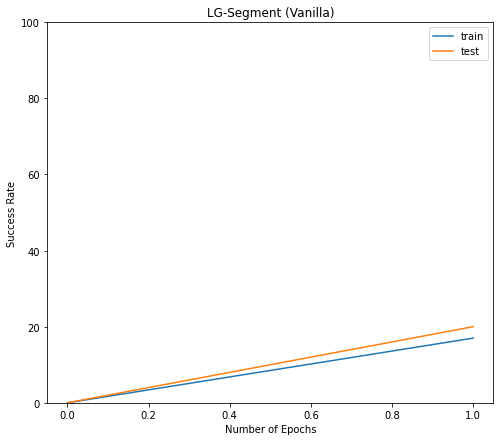

====================Epoch = 2======================
Training Step = 0	Training MSE Loss = 0.017
Training Step = 100	Training MSE Loss = 0.01802
Training Step = 200	Training MSE Loss = 0.01723
Training Step = 300	Training MSE Loss = 0.01704
Training Step = 400	Training MSE Loss = 0.01696
Training Step = 500	Training MSE Loss = 0.01695
Training Step = 600	Training MSE Loss = 0.01695
Training Step = 700	Training MSE Loss = 0.0166
Training Step = 800	Training MSE Loss = 0.01672
Training Step = 900	Training MSE Loss = 0.01601
Training Step = 1000	Training MSE Loss = 0.01606
Training Step = 1100	Training MSE Loss = 0.01584
Training Step = 1200	Training MSE Loss = 0.01597
Training Step = 1300	Training MSE Loss = 0.0154
Training Step = 1400	Training MSE Loss = 0.01553
Training Step = 1500	Training MSE Loss = 0.01543
Training Step = 1600	Training MSE Loss = 0.0156
Training Step = 1700	Training MSE Loss = 0.01515
====================Epoch = 3======================
Training Step = 0	Training MSE 

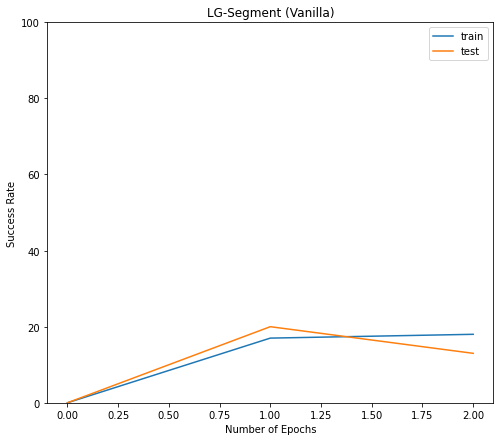

====================Epoch = 7======================
Training Step = 0	Training MSE Loss = 0.00981
Training Step = 100	Training MSE Loss = 0.01046
Training Step = 200	Training MSE Loss = 0.01007
Training Step = 300	Training MSE Loss = 0.01038
Training Step = 400	Training MSE Loss = 0.01017
Training Step = 500	Training MSE Loss = 0.01
Training Step = 600	Training MSE Loss = 0.01035
Training Step = 700	Training MSE Loss = 0.01009
Training Step = 800	Training MSE Loss = 0.01034
Training Step = 900	Training MSE Loss = 0.01016
Training Step = 1000	Training MSE Loss = 0.01051
Training Step = 1100	Training MSE Loss = 0.01034
Training Step = 1200	Training MSE Loss = 0.01023
Training Step = 1300	Training MSE Loss = 0.01011
Training Step = 1400	Training MSE Loss = 0.01022
Training Step = 1500	Training MSE Loss = 0.00999
Training Step = 1600	Training MSE Loss = 0.00999
Training Step = 1700	Training MSE Loss = 0.00974
====================Epoch = 8======================
Training Step = 0	Training MS

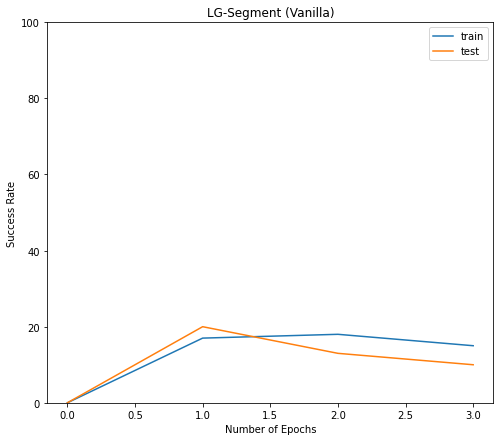

====================Epoch = 12======================
Training Step = 0	Training MSE Loss = 0.00811
Training Step = 100	Training MSE Loss = 0.00836
Training Step = 200	Training MSE Loss = 0.00832
Training Step = 300	Training MSE Loss = 0.00814
Training Step = 400	Training MSE Loss = 0.00831
Training Step = 500	Training MSE Loss = 0.00803
Training Step = 600	Training MSE Loss = 0.00839
Training Step = 700	Training MSE Loss = 0.00828
Training Step = 800	Training MSE Loss = 0.00817
Training Step = 900	Training MSE Loss = 0.00827
Training Step = 1000	Training MSE Loss = 0.00812
Training Step = 1100	Training MSE Loss = 0.00806
Training Step = 1200	Training MSE Loss = 0.00832
Training Step = 1300	Training MSE Loss = 0.00824
Training Step = 1400	Training MSE Loss = 0.00831
Training Step = 1500	Training MSE Loss = 0.00818
Training Step = 1600	Training MSE Loss = 0.008
Training Step = 1700	Training MSE Loss = 0.0082
====================Epoch = 13======================
Training Step = 0	Training 

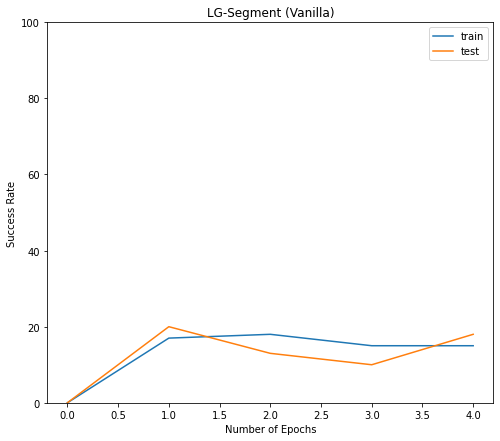

====================Epoch = 17======================
Training Step = 0	Training MSE Loss = 0.00692
Training Step = 100	Training MSE Loss = 0.00746
Training Step = 200	Training MSE Loss = 0.00699
Training Step = 300	Training MSE Loss = 0.00703
Training Step = 400	Training MSE Loss = 0.00702
Training Step = 500	Training MSE Loss = 0.00722
Training Step = 600	Training MSE Loss = 0.00701
Training Step = 700	Training MSE Loss = 0.0069
Training Step = 800	Training MSE Loss = 0.00734
Training Step = 900	Training MSE Loss = 0.00711
Training Step = 1000	Training MSE Loss = 0.00703
Training Step = 1100	Training MSE Loss = 0.00708
Training Step = 1200	Training MSE Loss = 0.00726
Training Step = 1300	Training MSE Loss = 0.00736
Training Step = 1400	Training MSE Loss = 0.00711
Training Step = 1500	Training MSE Loss = 0.00726
Training Step = 1600	Training MSE Loss = 0.00749
Training Step = 1700	Training MSE Loss = 0.00704
====================Epoch = 18======================
Training Step = 0	Trainin

In [ ]:
results_dict = {}
alpha = 0

mse_losses, nll_losses = [], []
train_success, test_success  = [0], [0]
dnn = MLP(dropout=0.0, last_dim = 3).to(device)
reachable_model = MLP(dropout=0.0, last_dim = 1).to(device)
env = YAML(yaml_file='YAML/parking_lot_small.yaml')
reachable_model = torch.load('parking-lot-lg/reachability_predictor.pt')
success_rate = train_dnn(dnn.to(device), reachable_model.to(device), train=train_lg_data.DataLoader, epochs=20, lr=1e-3, alpha = alpha)
results_dict[alpha ] = success_rate
print(results_dict)

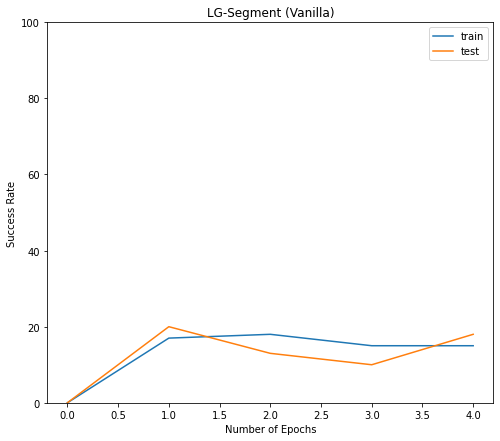

In [ ]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.title('Success Rates')
plt.plot(train_success, label='train')
plt.plot(test_success, label='test')
plt.ylabel('Success Rate')
plt.xlabel('Number of Epochs')
plt.title('LG-Segment (Vanilla)')
plt.legend()
plt.ylim(0,100)
plt.show()

In [ ]:
m1, n1 = [], []
m, n = 0, 0
for i in range(len(mse_losses)):
    m += mse_losses[i]
    n += nll_losses[i]
    if i%10==0:
        m1 += [m/10]
        n1 += [n/10]
        m, n = 0, 0

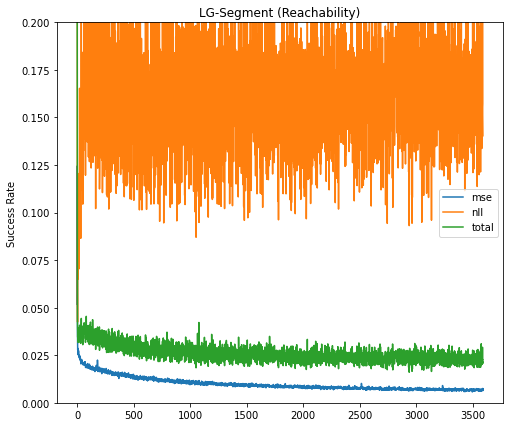

In [ ]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.title('Success Rates')
plt.plot(m1, label='mse')
plt.plot(n1, label='nll')
plt.plot(np.array(m1)+0.1*np.array(n1), label = 'total')
plt.ylabel('Success Rate')
# plt.xlabel('Number of Epochs')
plt.title('LG-Segment (Reachability)')
plt.legend()
plt.ylim(0,0.2)
plt.show()

In [ ]:
torch.save(dnn.to('cpu'), 'parking-lot-lg/vanilla_lg.pt')

In [ ]:
dnn = torch.load('narrow-lg/reachability_aware_lg_passage2x.pt')

In [ ]:
reachable_model = torch.load('narrow-lg/reachability_predictor_passage2.pt')

In [ ]:
example = torch.rand(1,8)
dnn.eval()
with torch.jit.optimized_execution(True):
    traced_script_module = torch.jit.trace(dnn.to('cpu'),example)
traced_script_module.save('narrow-lg/lg_torchscript.pt')

In [ ]:
example = torch.rand(1,8)
reachable_model.eval()
with torch.jit.optimized_execution(True):
    traced_script_module = torch.jit.trace(reachable_model.to('cpu'),example)
traced_script_module.save('narrow-lg/reachable_torchscript.pt')

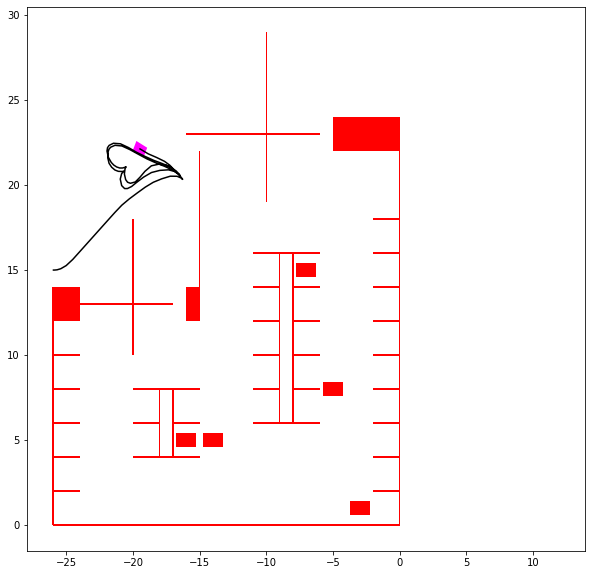

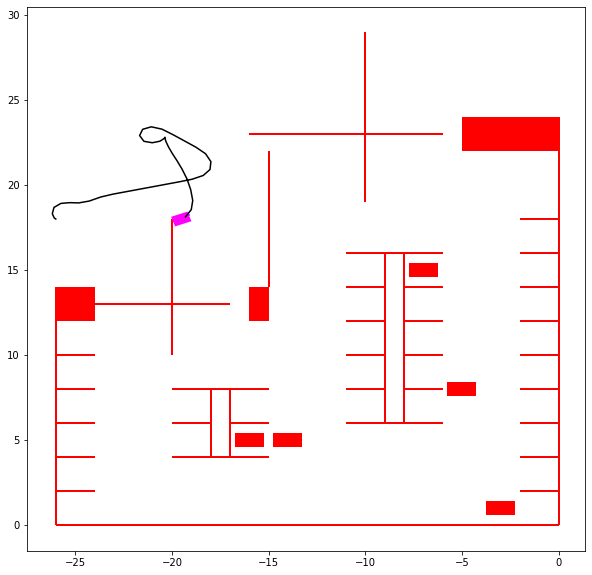

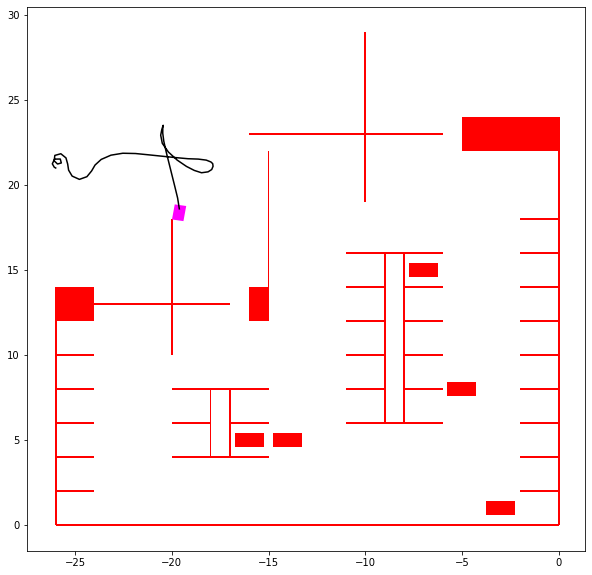

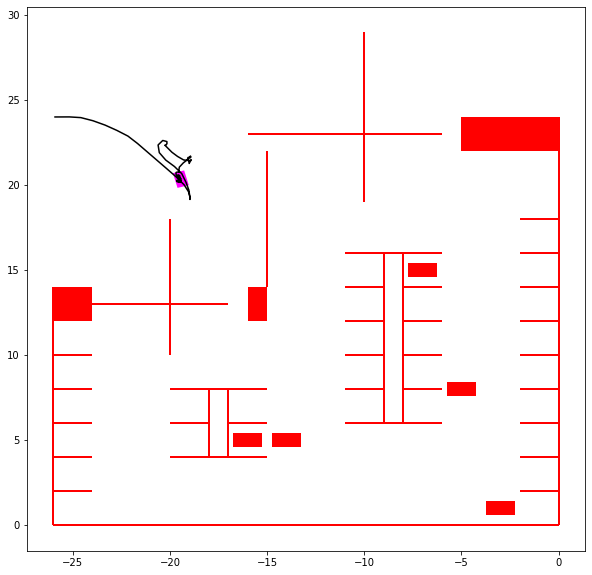

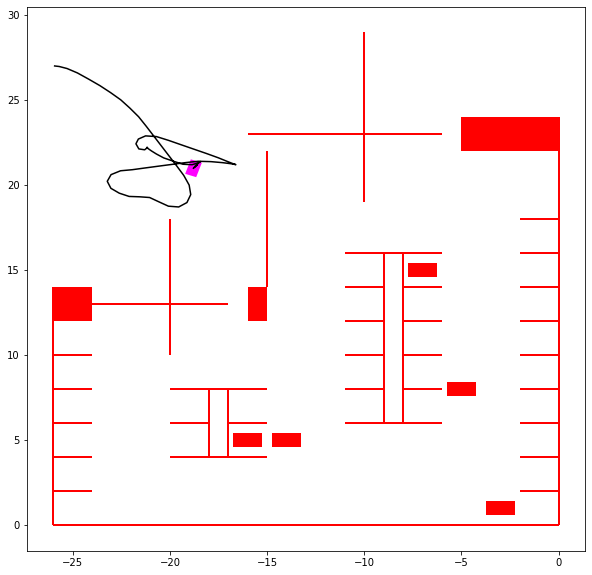

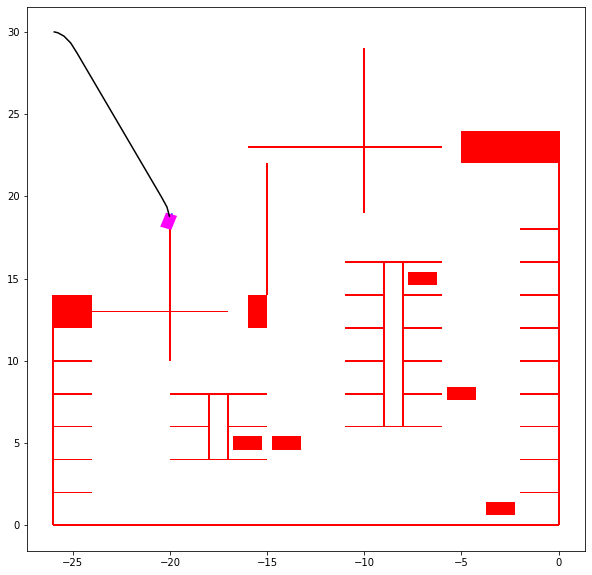

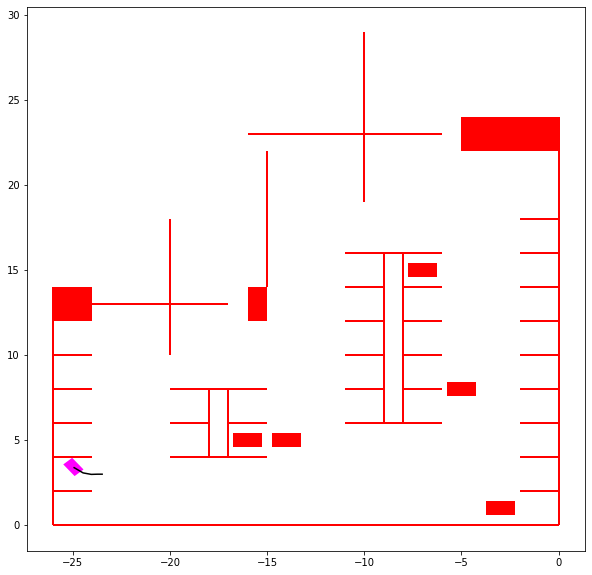

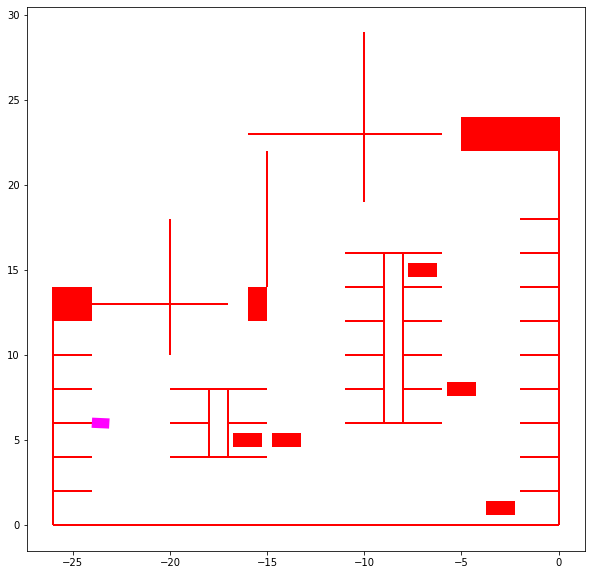

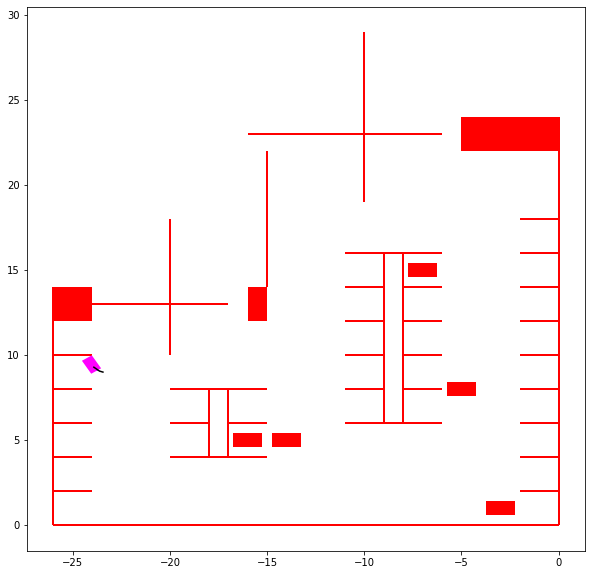

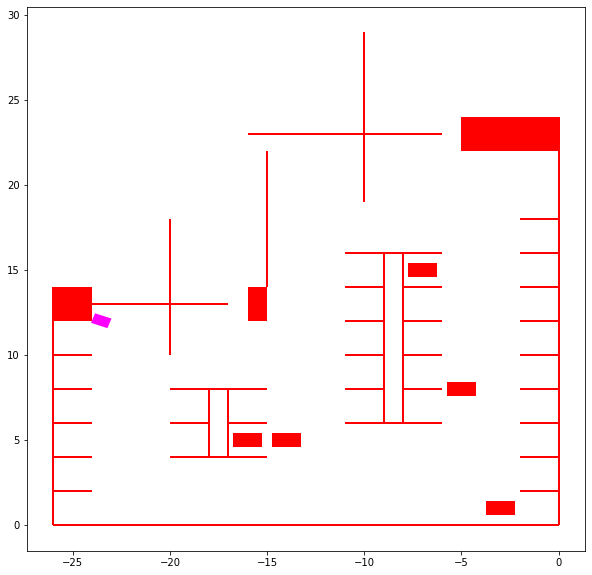

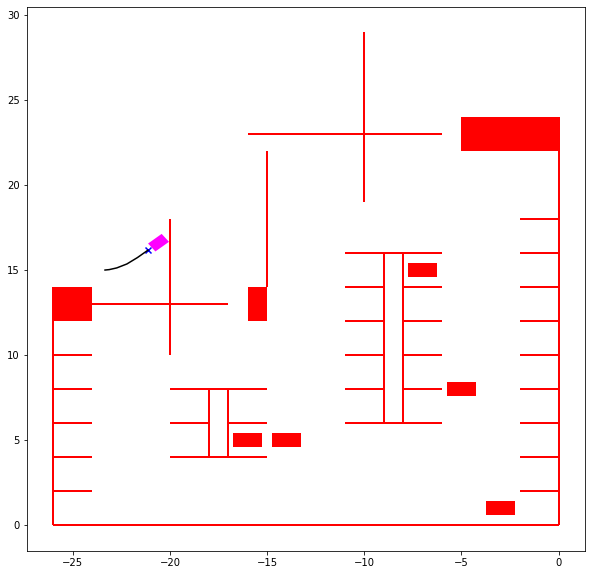

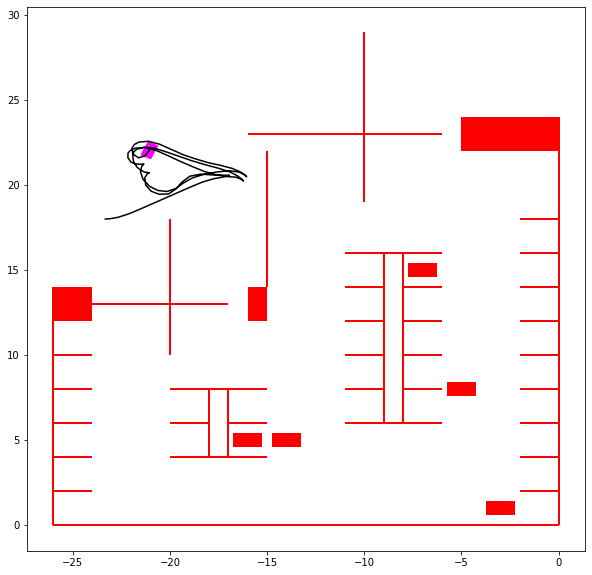

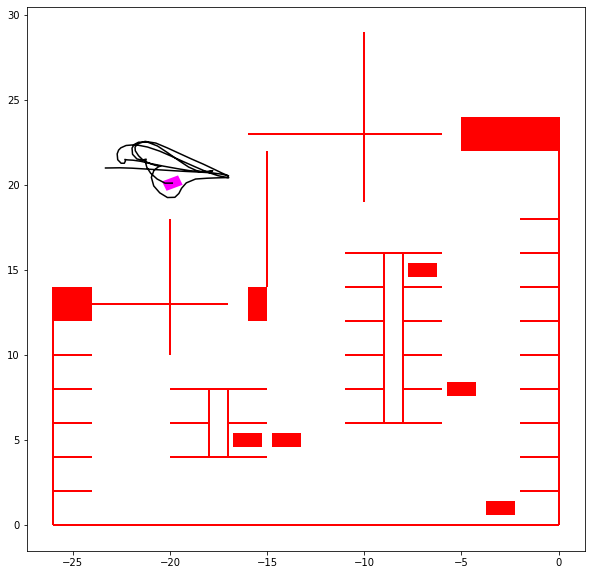

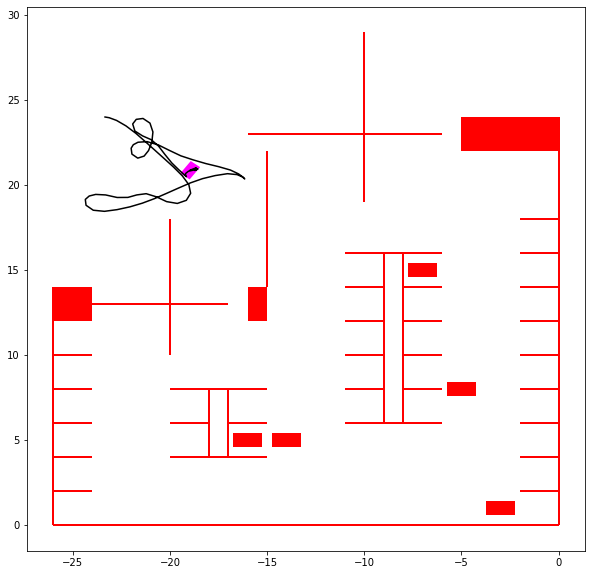

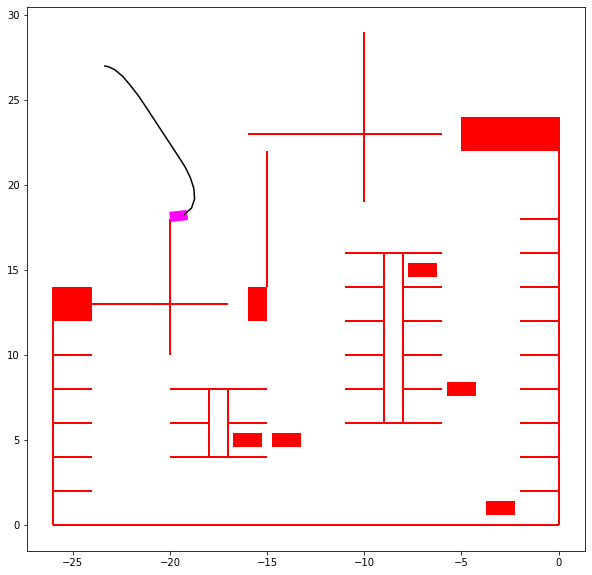

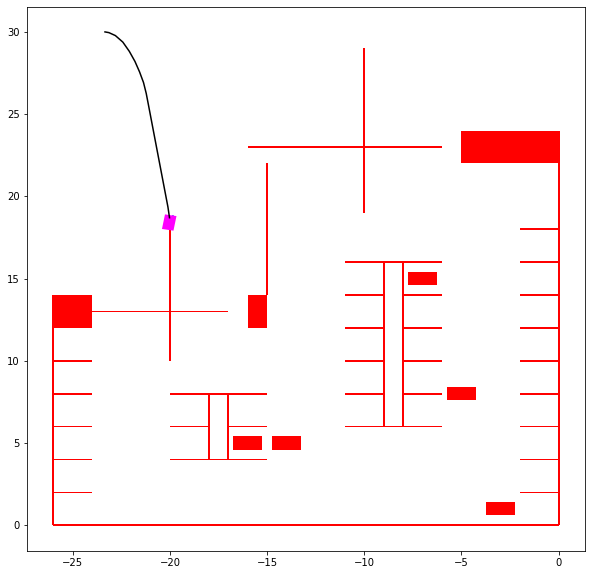

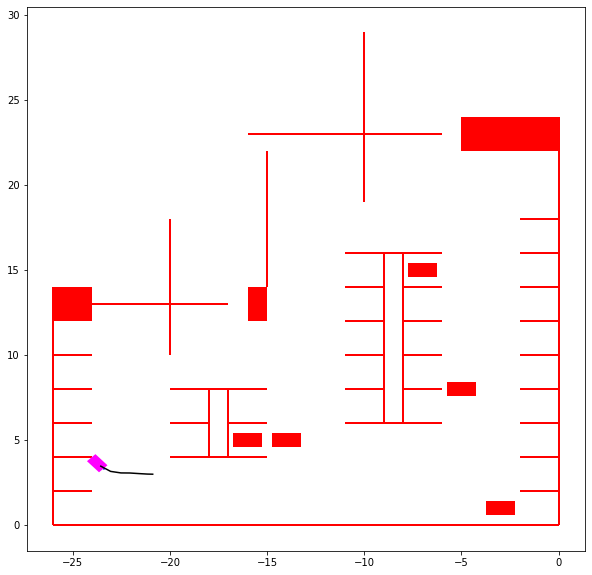

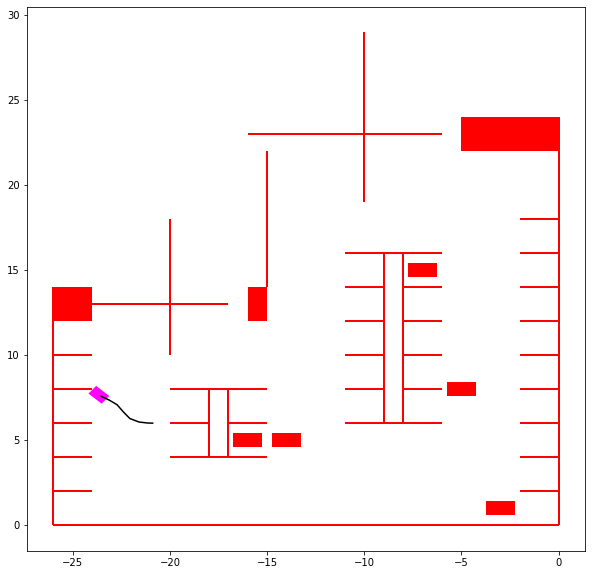

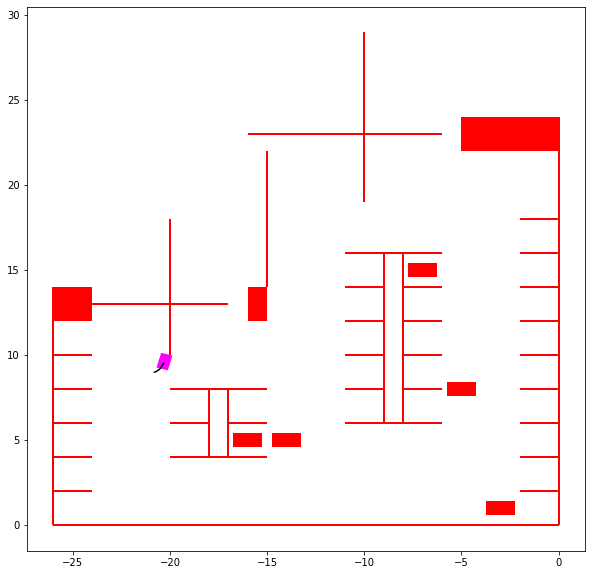

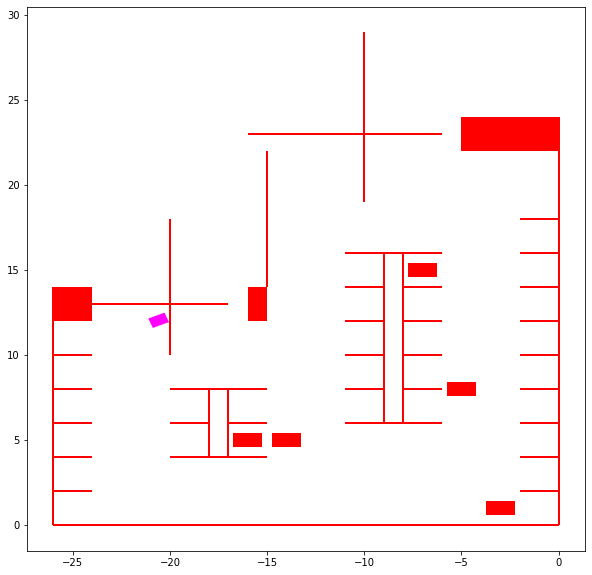

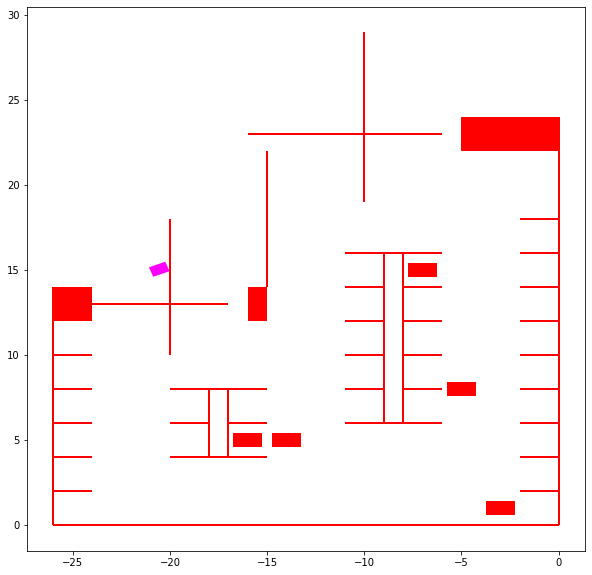

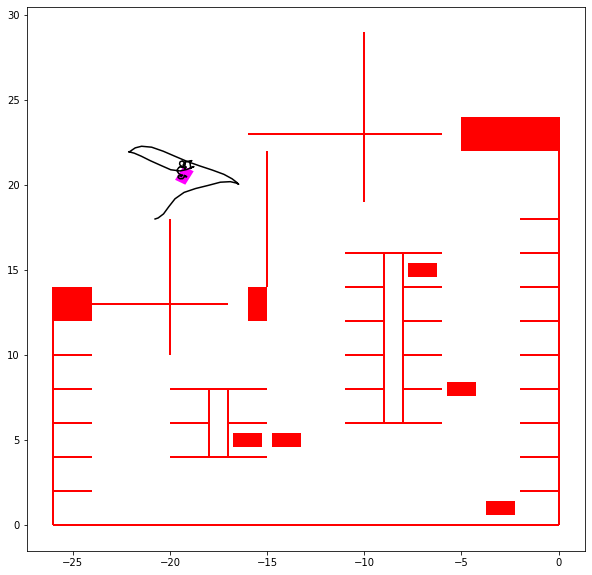

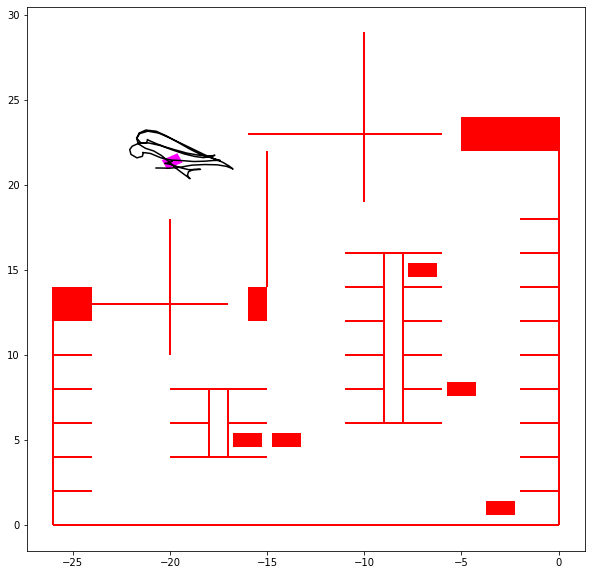

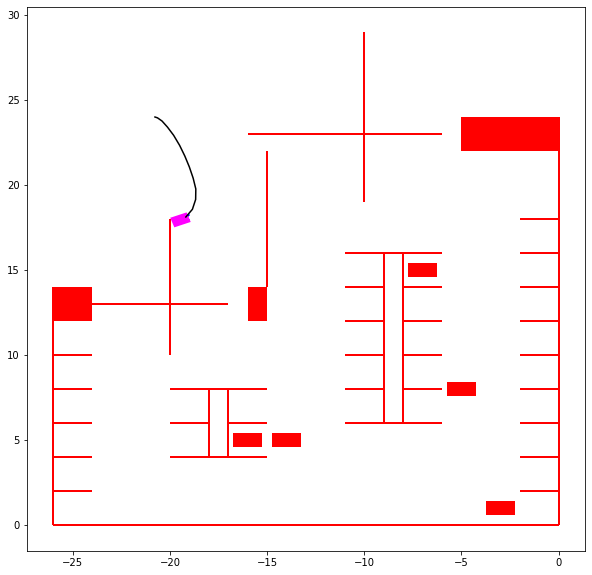

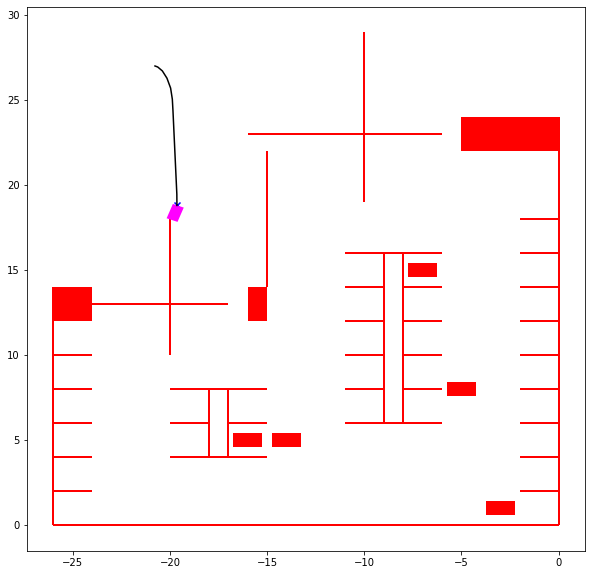

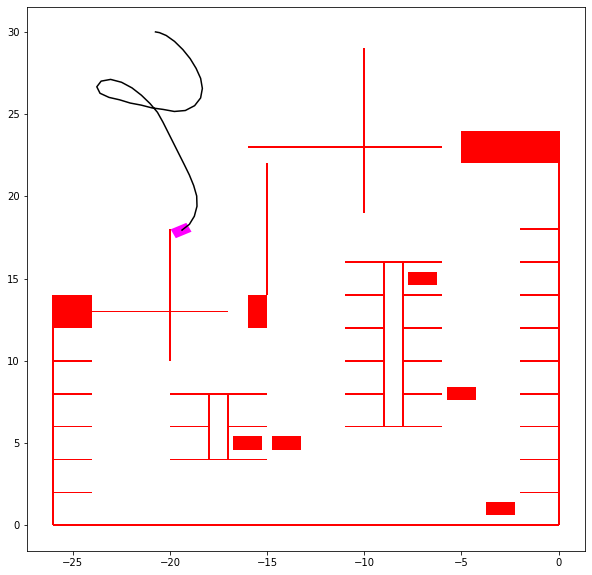

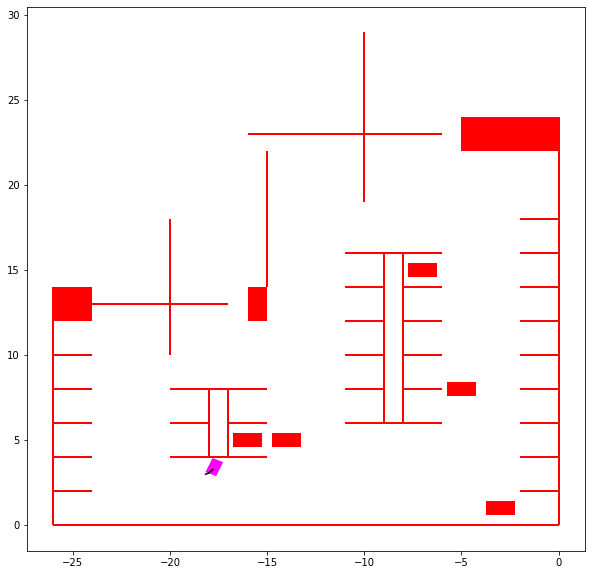

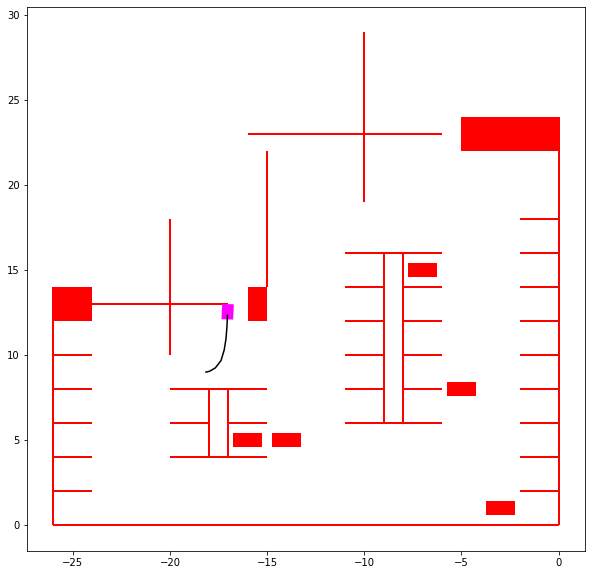

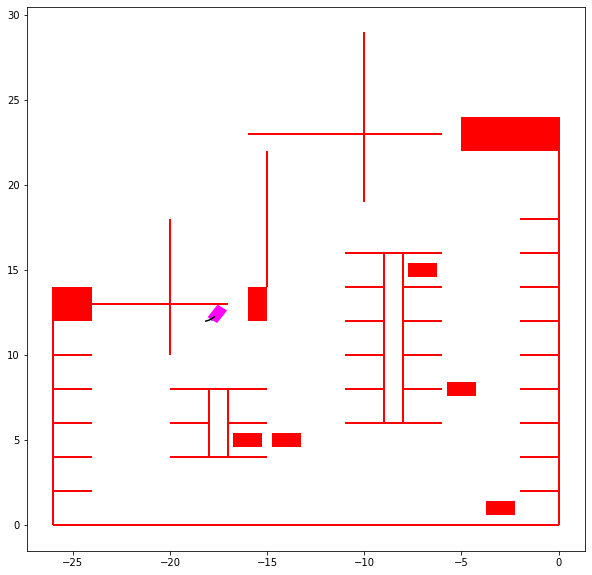

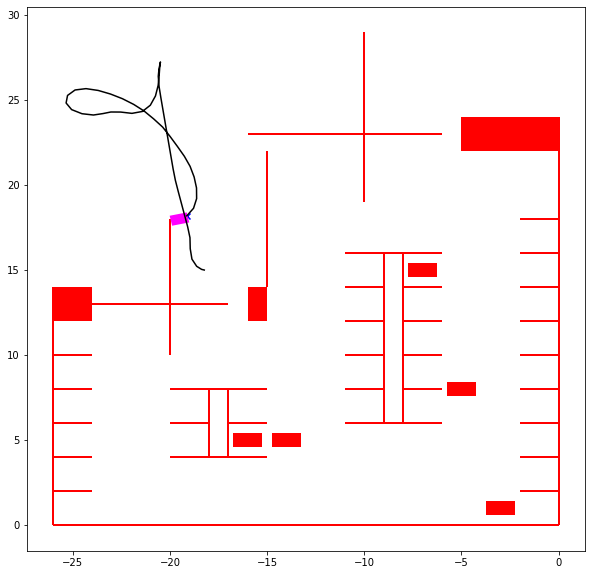

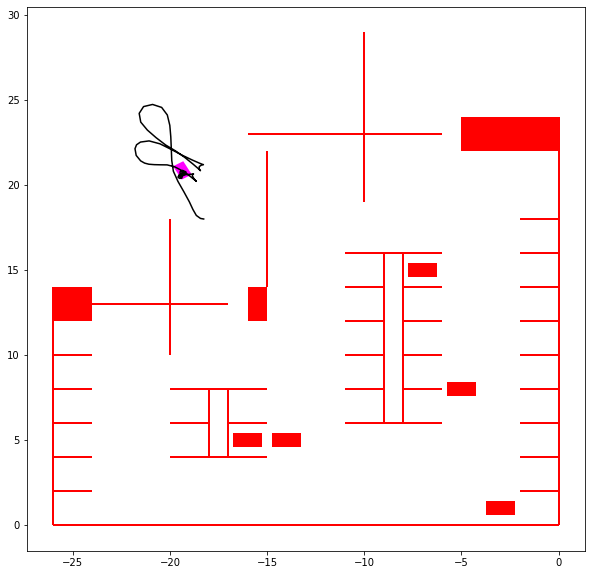

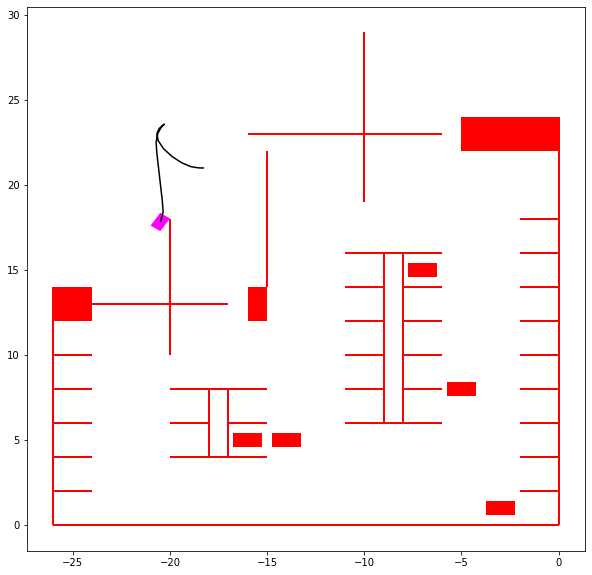

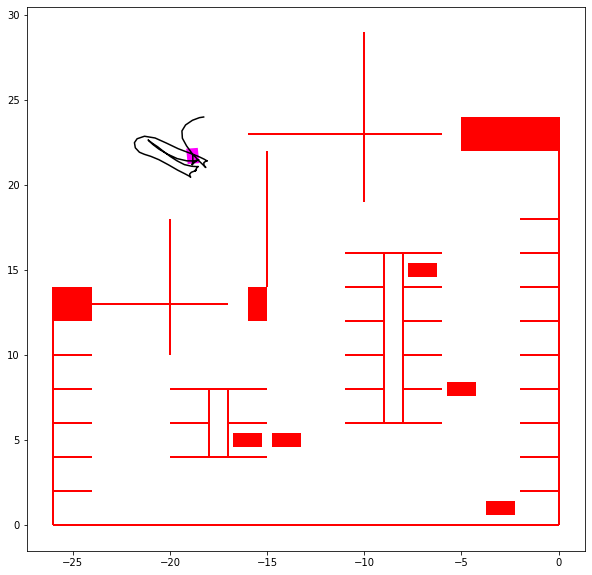

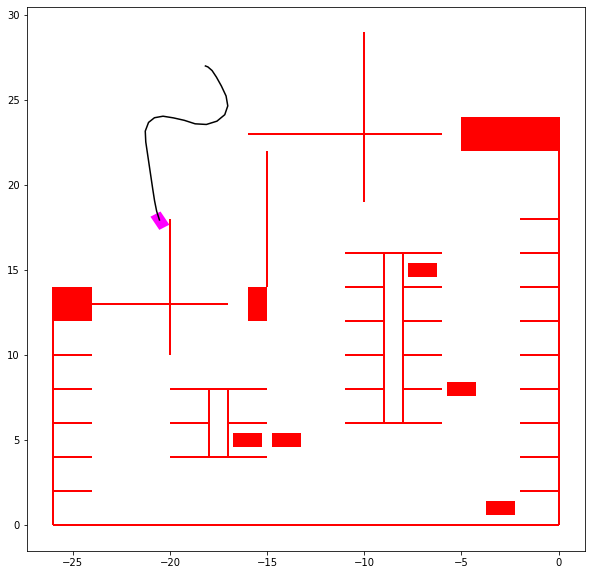

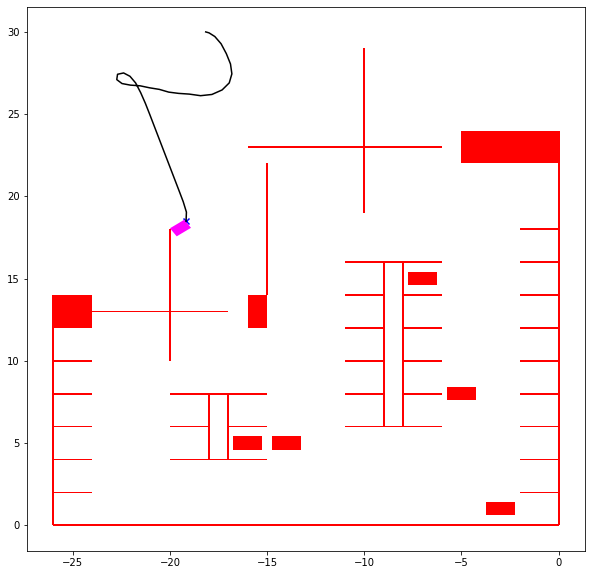

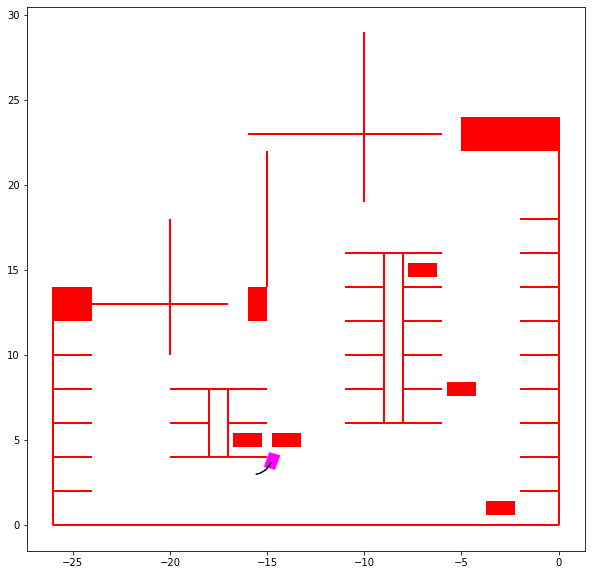

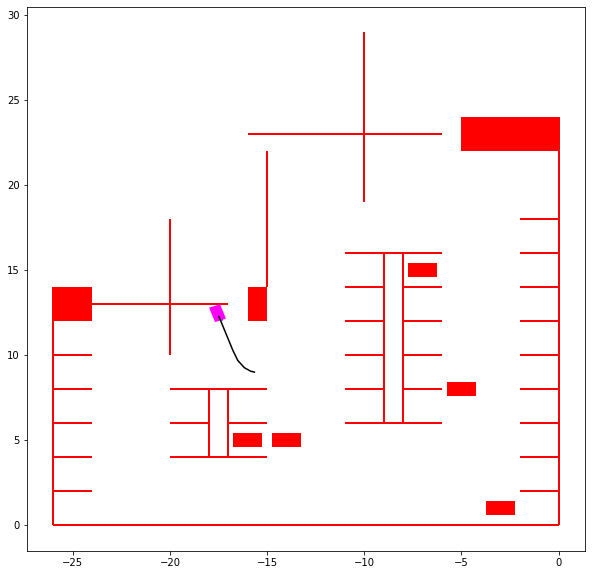

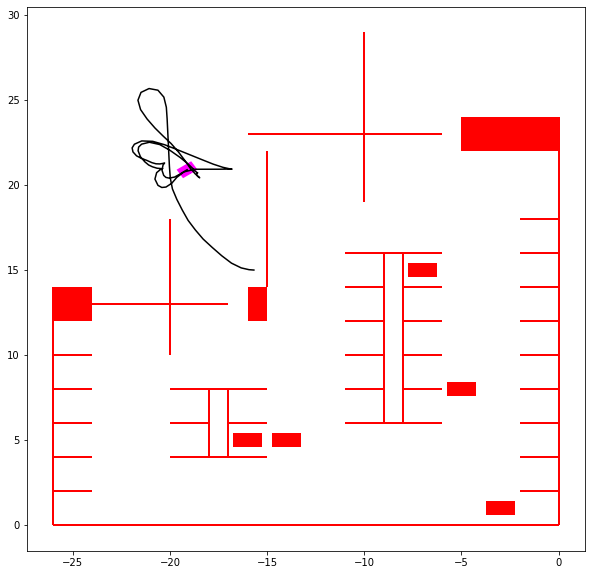

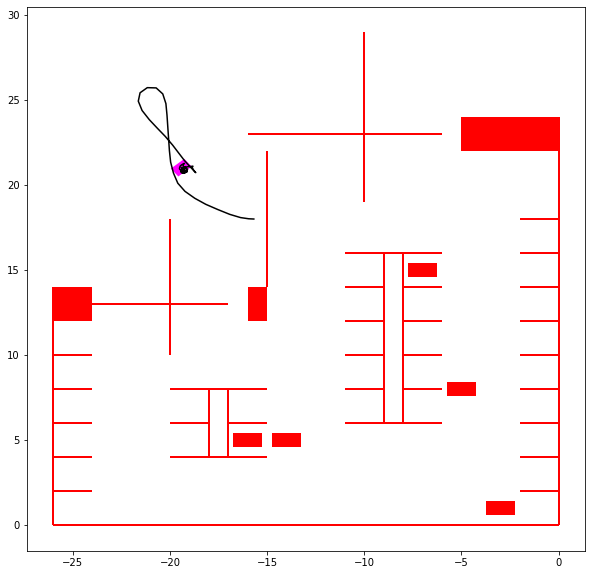

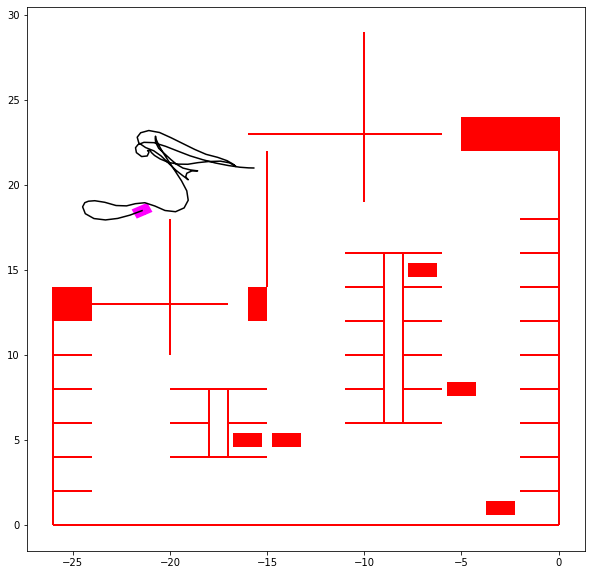

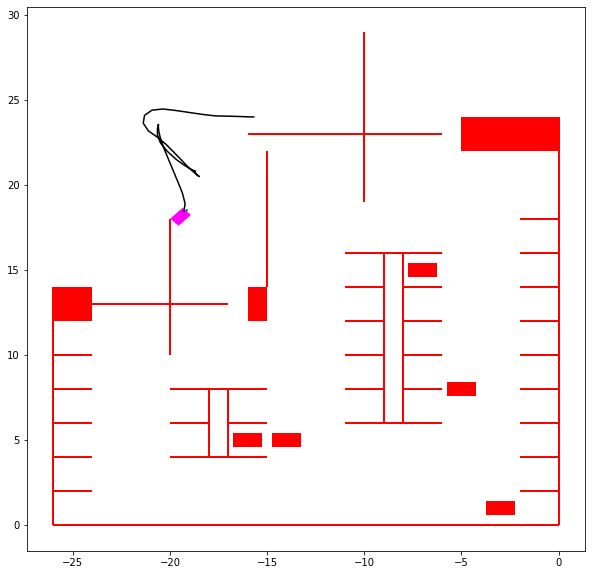

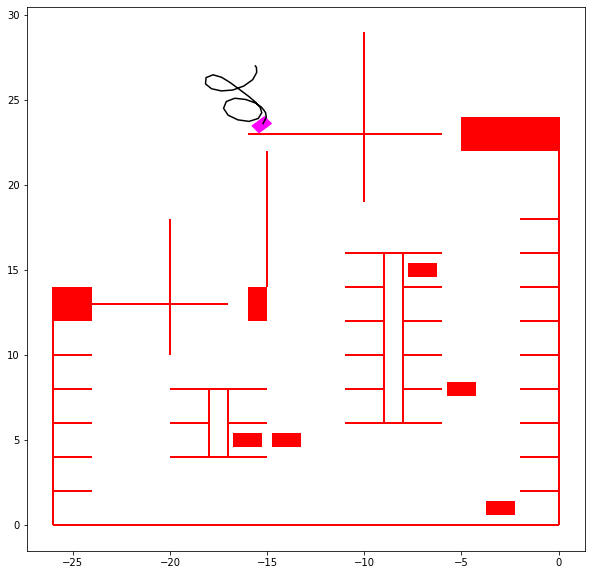

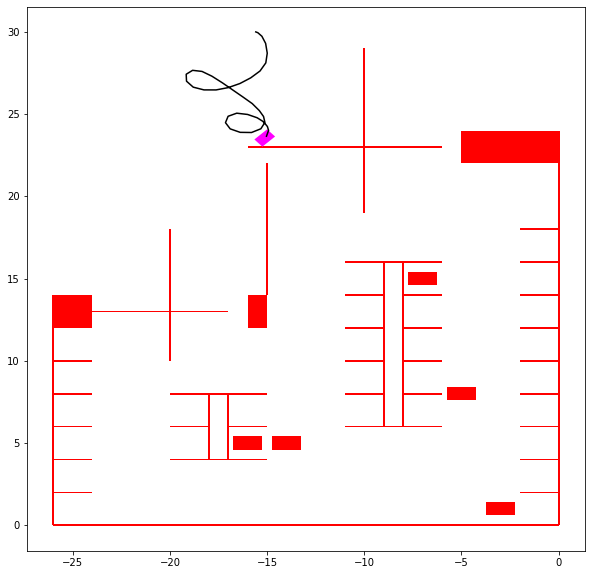

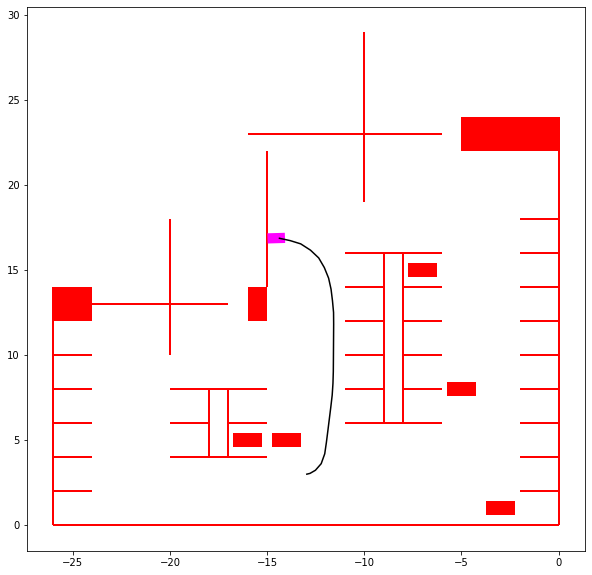

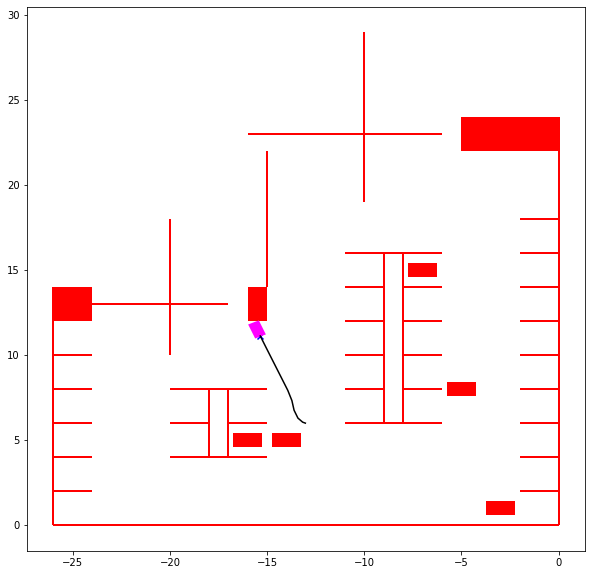

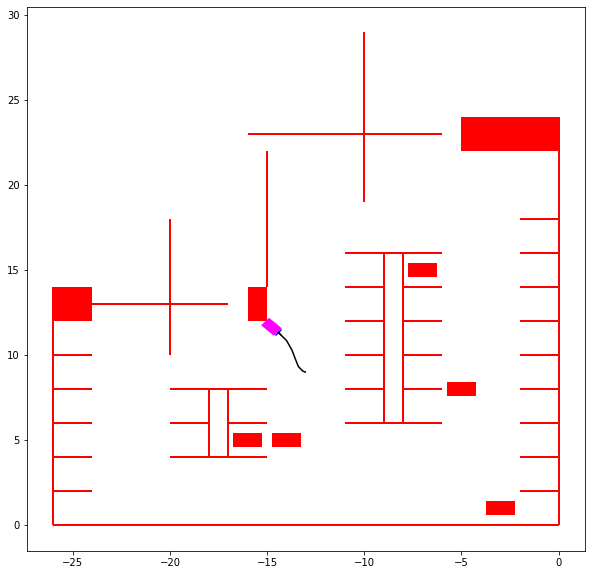

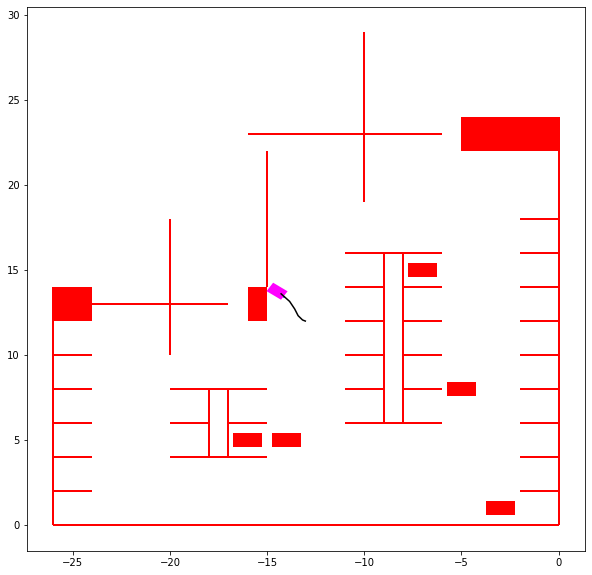

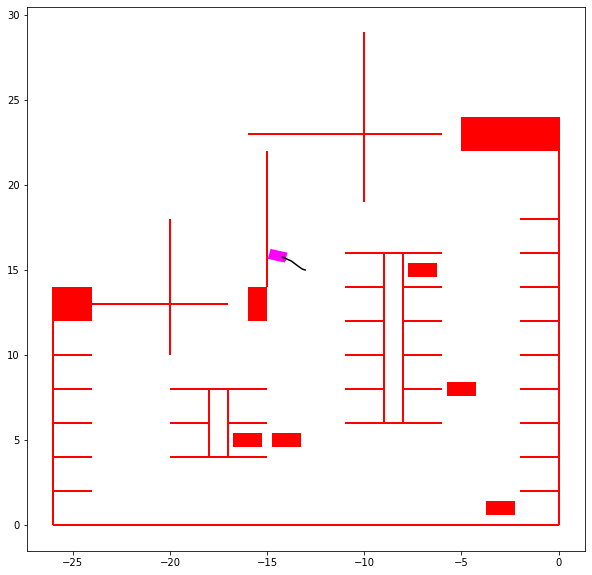

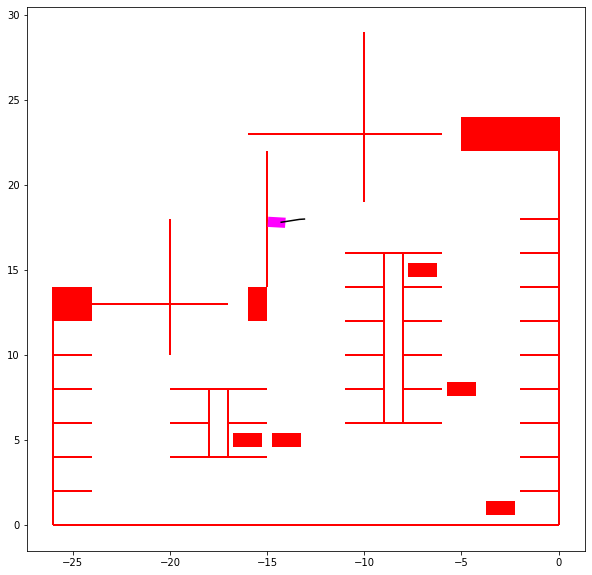

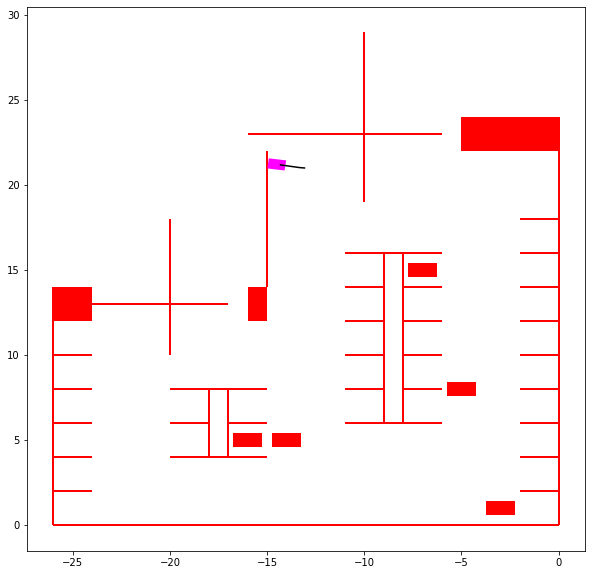

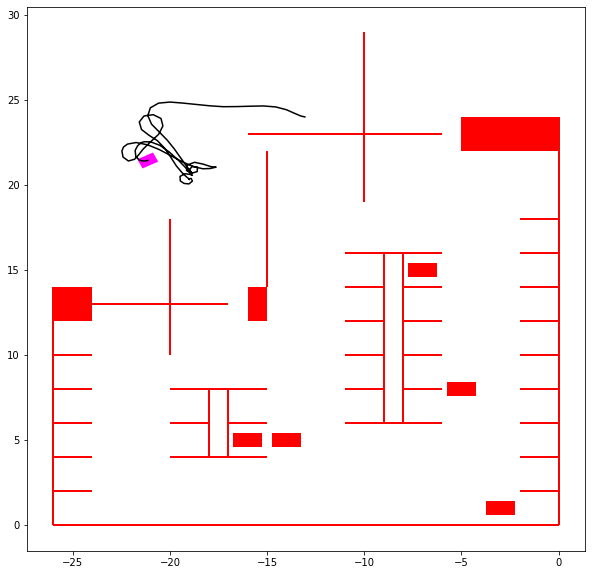

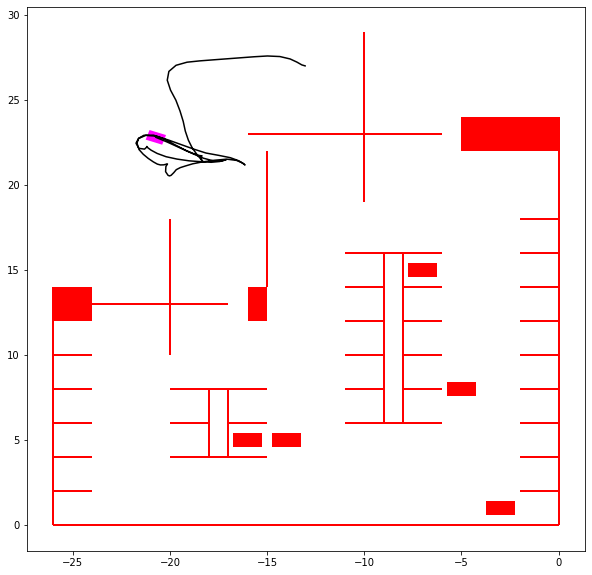

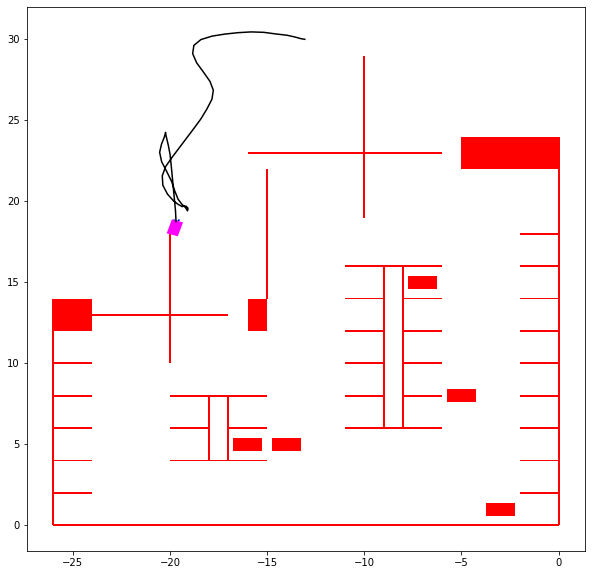

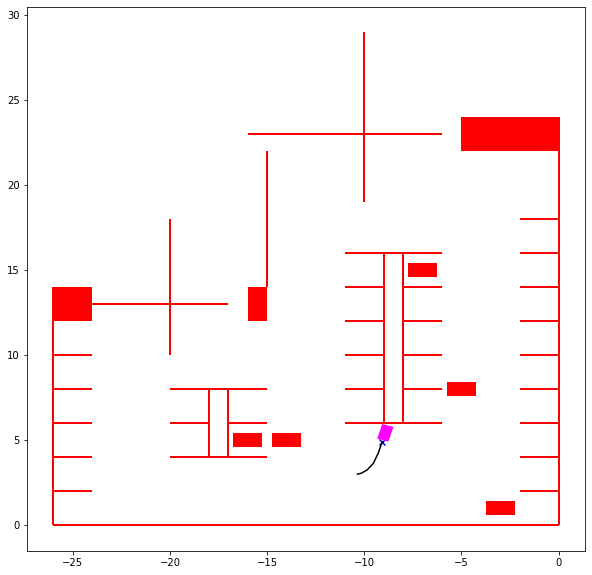

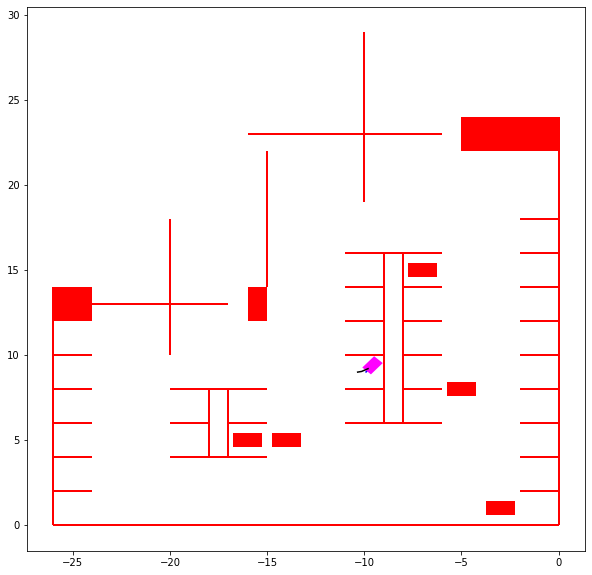

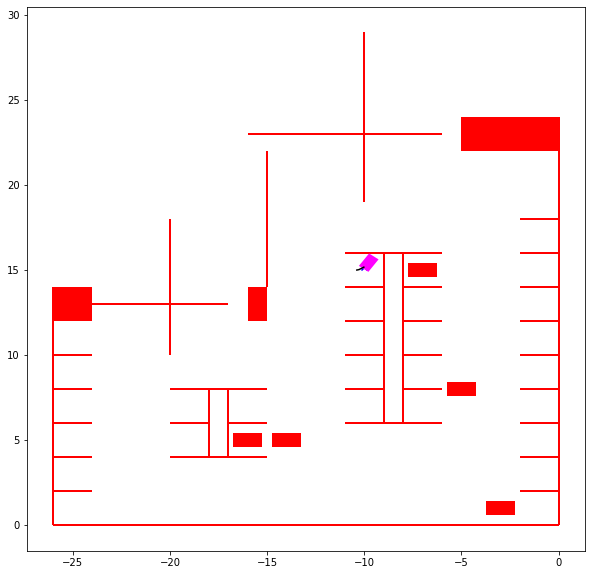

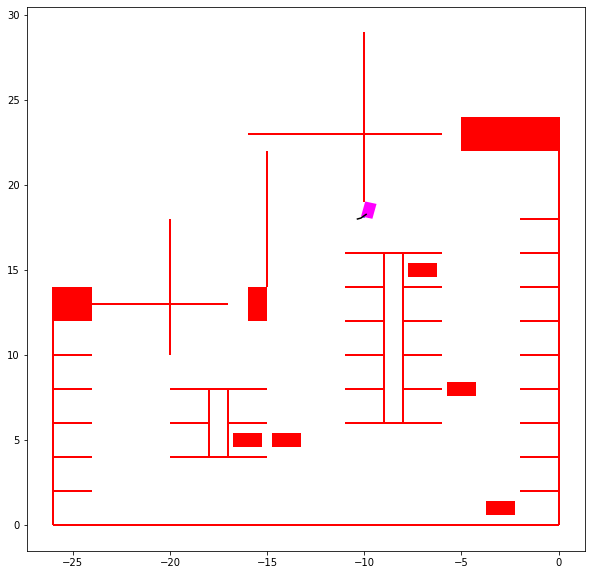

IndexError: ignored

In [ ]:
# lg_model = torch.jit.load(f'../{city_name}/mlp_old.pt')
# lg_model.eval()
plt.rcParams['figure.figsize'] = [10, 10]
# plt.subplot(2,1, 1)
env.body = None
env.plot_env()
dnn.to('cpu')
reachable_model.to('cpu')
DIM = 10
RES_X = 26/DIM
RES_Y = 30/DIM
variances = np.zeros((DIM+1,DIM+1))
g = np.array([12.0, 12.0, 0, 0, 0])
# g = g*0

start_region = plt.Circle(((g[0]),(g[1])),0,color='red')
plt.gca().add_patch(start_region)

sig = torch.nn.Sigmoid()
for i in range(DIM+1):
    for j in range(DIM+1):
        # print(i, j)
        dnn.to('cpu')
        reachable_model.to('cpu')
        s = np.array([i*RES_X-26, j*RES_Y, np.pi/2, 0, 0])
        if not env.valid_state(s): continue
        traj = []
        variance = []
        # for k in range(200):
        lg_start = env.preprocess_state(list(np.copy(s)))
        lg_goal = env.preprocess_state(list(g[:3]))
        inp = lg_start + lg_goal
        reachability = (sig(reachable_model(torch.Tensor([lg_start+lg_goal]))).detach().cpu().numpy())
        # print(float(reachability))
        # break
        # if reachability < 0.5: continue
        variance = (dnn(torch.Tensor([lg_start+lg_goal])).detach().cpu().numpy())
        mean = env.decode_state(np.array(variance).mean(axis = 0))
        # plt.text(city.convert(s[0]), city.convert(s[1]), to_plot, color = 'red')
        traj, success, goal = check_model(dnn.to('cuda'), reachable_model.to('cuda'), env, s, g)
        traj = np.array(traj)
        # plt.scatter(s[0], s[1],marker='x', color='green')
        plt.plot(traj[:,0],traj[:,1], color='black')

        idx = min(100, len(traj)-1)
        mean = traj[-1]
        plt.scatter(mean[0], mean[1],marker='x', color='blue')
        # env.body = None
        env.plot_env()  
        plt.show()
        # plt.arrow((s[0]),(s[1]), (mean[0])-(s[0]), (mean[1])-(s[1]), width = 0.001, head_width = 0.25)

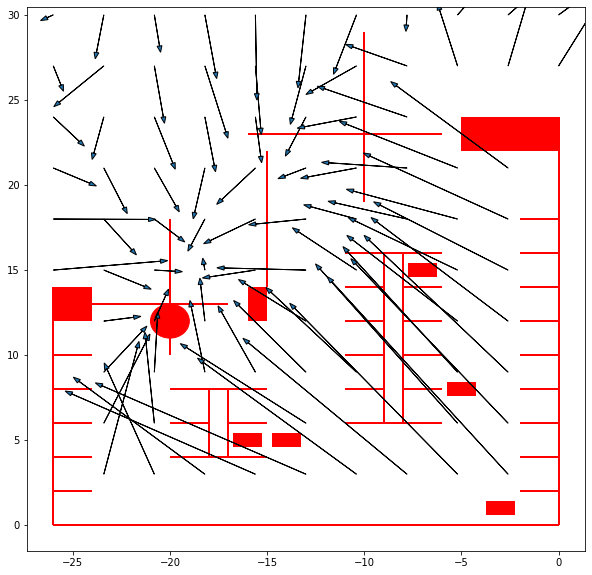

In [ ]:
# lg_model = torch.jit.load(f'../{city_name}/mlp_old.pt')
# lg_model.eval()
plt.rcParams['figure.figsize'] = [10, 10]
# plt.subplot(2,1, 1)
env.body = None
env.plot_env()
dnn.to('cpu')
DIM = 10
RES_X = 26/DIM
RES_Y = 30/DIM
variances = np.zeros((DIM+1,DIM+1))
g = np.array([-20.0, 12.0, 0, 0, 0])
# g = g*0

start_region = plt.Circle(((g[0]),(g[1])),1,color='red')
plt.gca().add_patch(start_region)

for i in range(DIM+1):
    for j in range(DIM+1):
        # print(i, j)
        s = np.array([i*RES_X-26, j*RES_Y, np.pi/2, 0, 0])
        
        traj = []
        variance = []
        # for k in range(200):
        lg_start = env.preprocess_state(list(np.copy(s)))
        lg_goal = env.preprocess_state(list(g[:3]))
        inp = lg_start + lg_goal
        variance = (dnn(torch.Tensor([lg_start+lg_goal])).detach().cpu().numpy())
        mean = env.decode_state(np.array(variance).mean(axis = 0))
        # plt.text(city.convert(s[0]), city.convert(s[1]), to_plot, color = 'red')
        if not env.valid_state(s): continue
        plt.arrow((s[0]),(s[1]), (mean[0])-(s[0]), (mean[1])-(s[1]), width = 0.001, head_width = 0.25)

In [ ]:
def get_traj(env, start = None, goal = None):
    while start is None or not env.valid_state(start):
        start = np.random.uniform(env.lows, env.highs)
    while goal is None or not env.valid_state(goal):
        goal = np.random.uniform(env.lows, env.highs)

    traj = []
    s = np.array([start[0], start[1], start[2], start[3], start[4]])
    g = np.array([goal[0], goal[1], goal[2], 0, 0])

    for k in range(100):
        action = actor_model(torch.Tensor([(list(s))+list(g[:3])]))[0].detach().cpu()
        for i in range(2):
            action[i] = np.clip(action[i],-1,1)
            action[i] = -0.2 + 0.4 * (action[i]+1)/2
        for i in range(10):
            s = env.propagate_once(np.copy(s), np.copy(list(action)))
            traj.append(np.copy(s))
        diff = env._enforce_bounds(s-g)[:3]
        if np.linalg.norm(diff) < 0.5: 
            success = True
            break
    return np.array(traj)

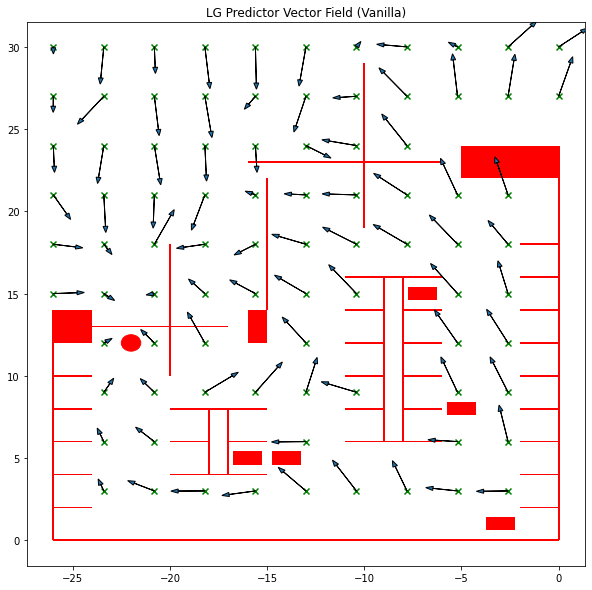

In [ ]:
# lg_model = torch.jit.load(f'../{city_name}/mlp_old.pt')
# lg_model.eval()
plt.rcParams['figure.figsize'] = [10, 10]
# plt.subplot(2,1, 1)
env.body = None
env.plot_env()
dnn.to('cpu')
DIM = 10
RES_X = 26/DIM
RES_Y = 30/DIM
variances = np.zeros((DIM+1,DIM+1))
g = np.array([-22.0, 12.0, 0, 0, 0])
# g = g*0

start_region = plt.Circle(((g[0]),(g[1])),0.5,color='red')
plt.gca().add_patch(start_region)

for i in range(DIM+1):
    for j in range(DIM+1):
        # print(i, j)
        s = np.array([i*RES_X-26, j*RES_Y, np.pi/2, 0, 0])
        
        traj = []
        variance = []
        # for k in range(200):
        lg_start = env.preprocess_state(list(np.copy(s)))
        lg_goal = env.preprocess_state(list(g[:3]))
        inp = lg_start + lg_goal
        variance = (dnn(torch.Tensor([lg_start+lg_goal])).detach().cpu().numpy())
        mean = env.decode_state(np.array(variance).mean(axis = 0))
        
        if not env.valid_state(s): continue
        traj = get_traj(env, start = s, goal = mean)
        plt.scatter(s[0], s[1],marker='x', color='green')
        # plt.plot(traj[:50,0],traj[:50,1], color='black')
        idx = min(50, len(traj)-1)
        mean = traj[idx]
        # plt.scatter(traj[0], traj[1],marker='x', color='green')
        plt.arrow((s[0]),(s[1]), (mean[0])-(s[0]), (mean[1])-(s[1]), width = 0.001, head_width = 0.25)
# plt.xlim(-15, 15)
# plt.ylim(-15, 15)
plt.title('LG Predictor Vector Field (Vanilla)')
plt.show()

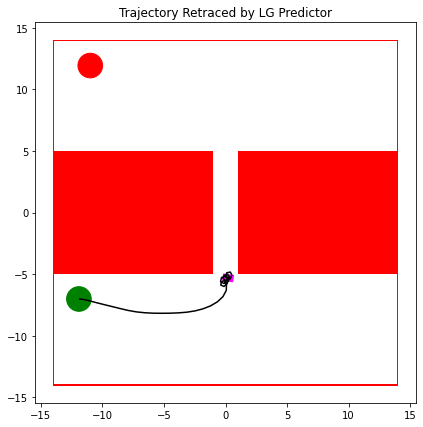

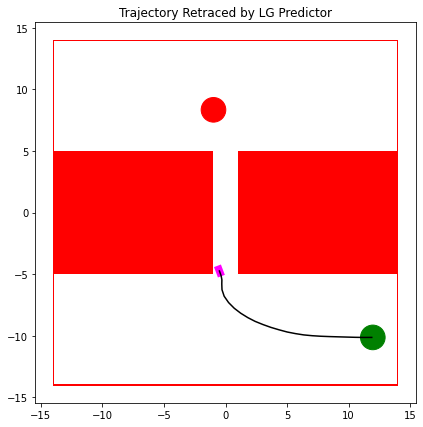

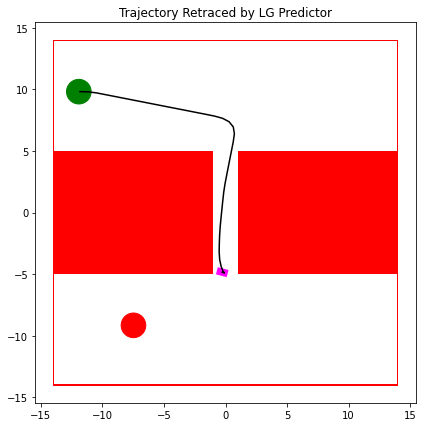

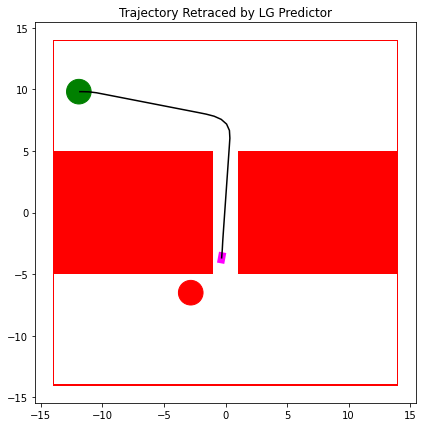

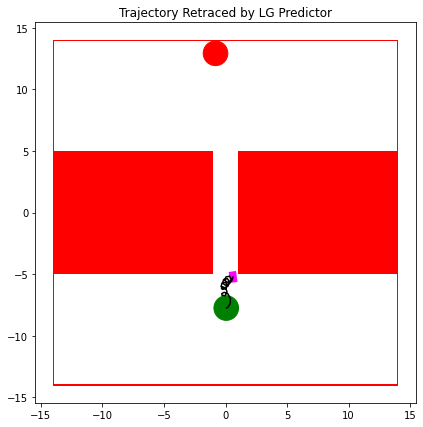

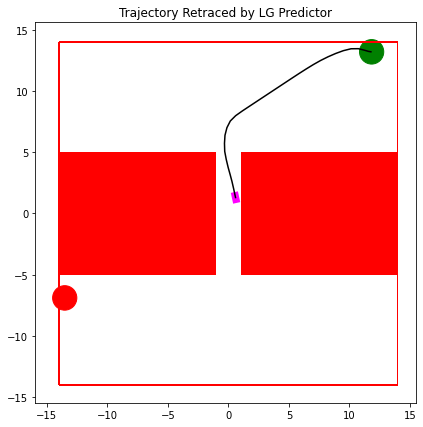

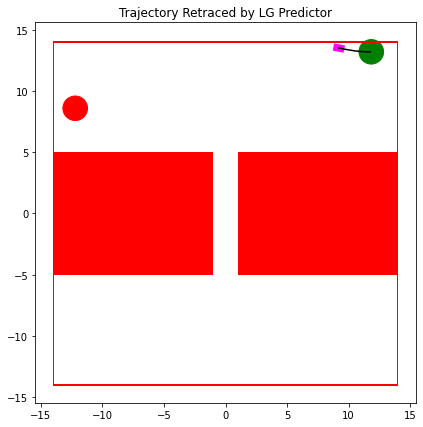

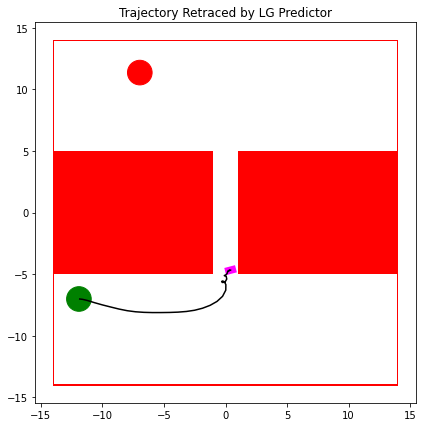

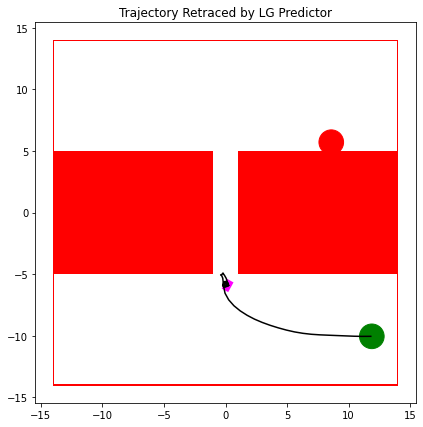

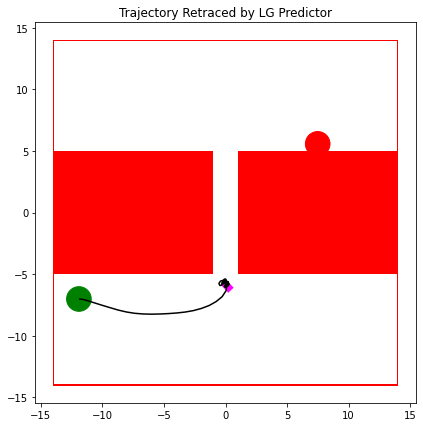

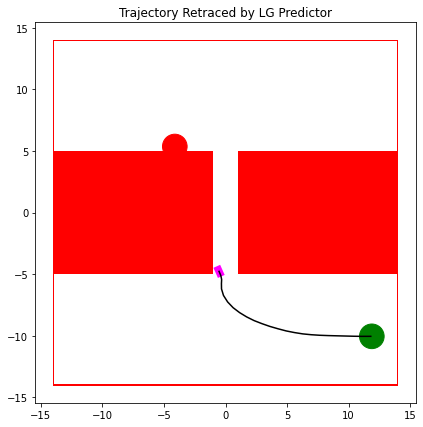

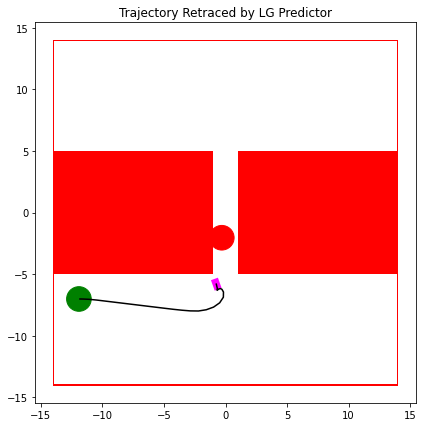

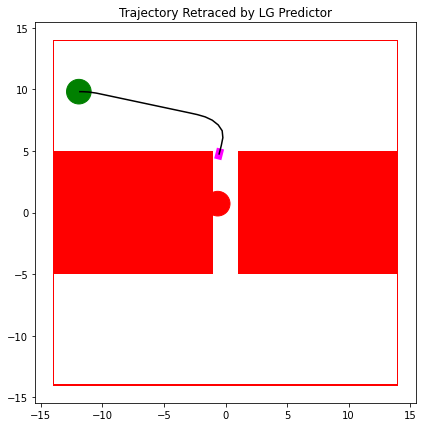

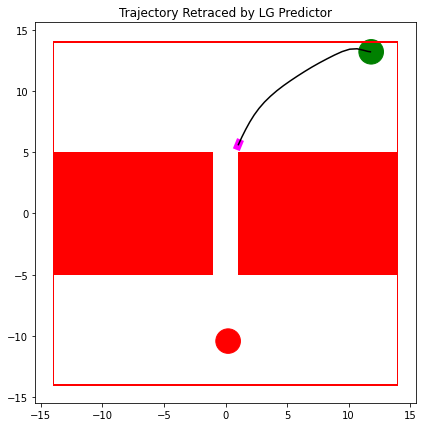

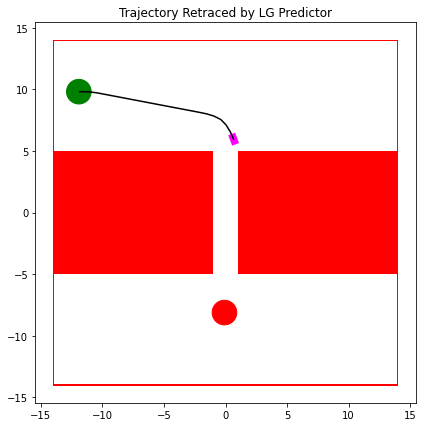

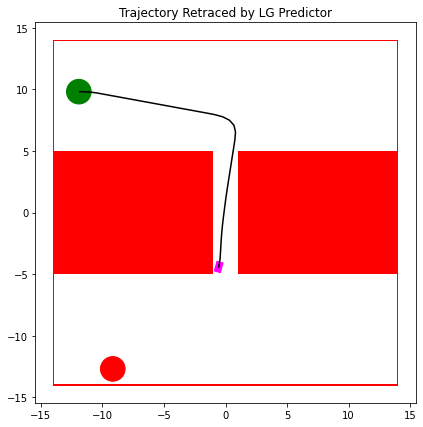

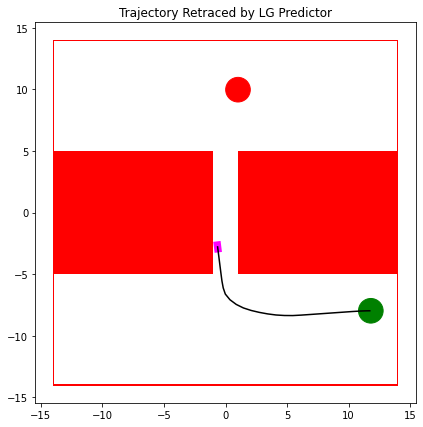

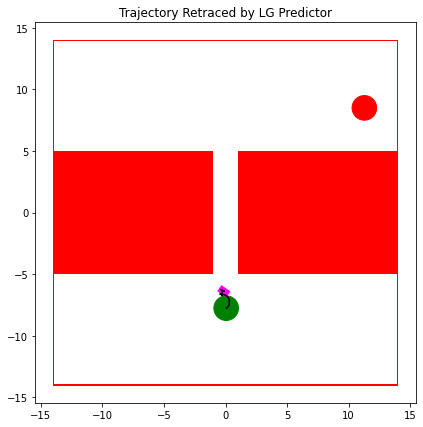

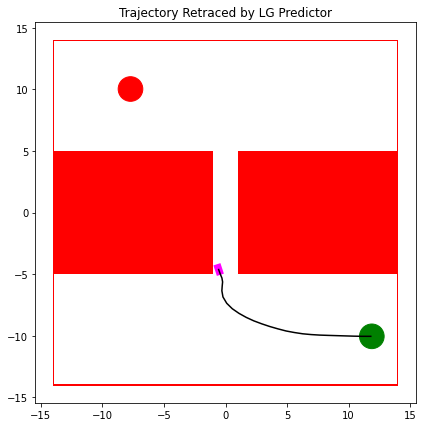

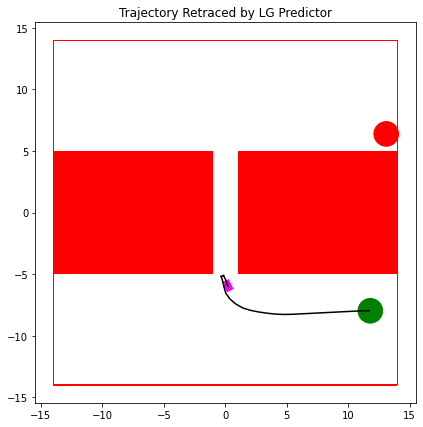

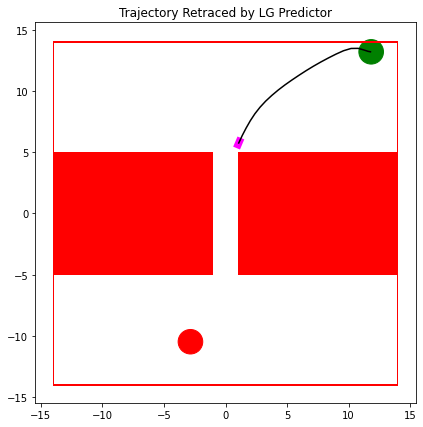

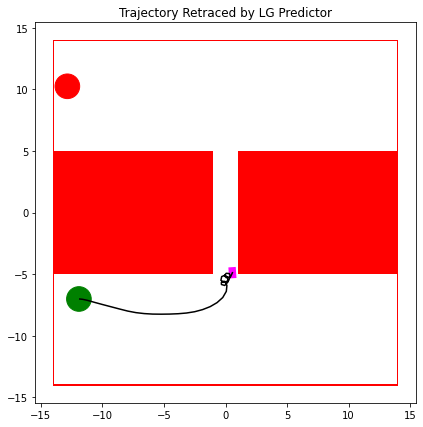

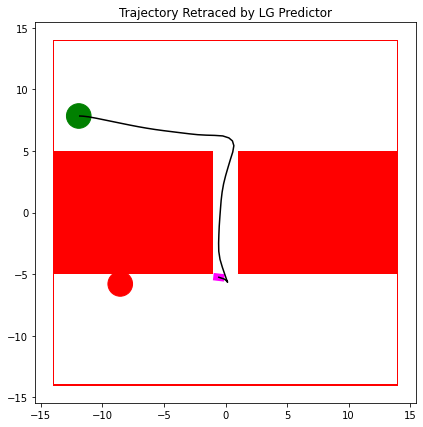

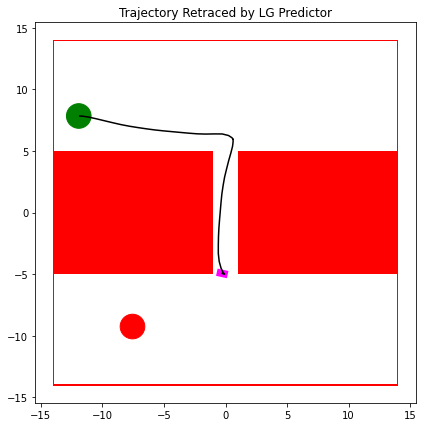

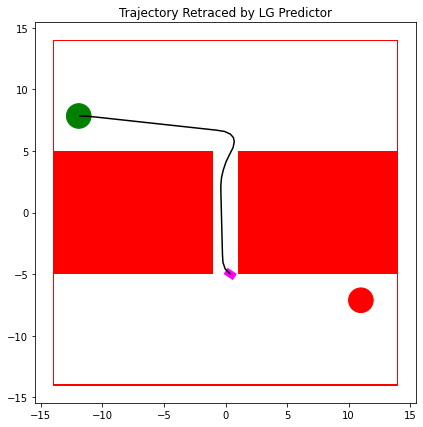

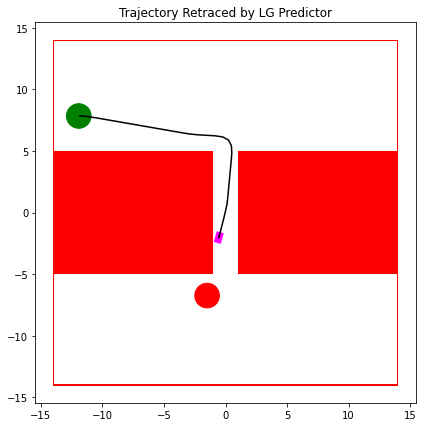

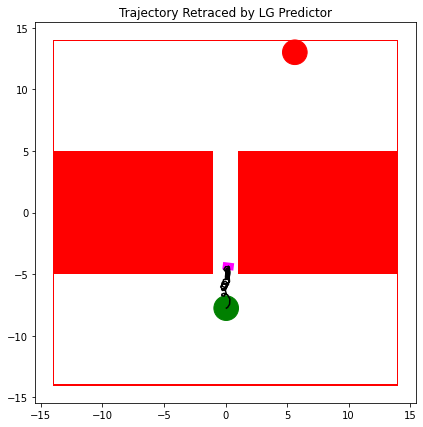

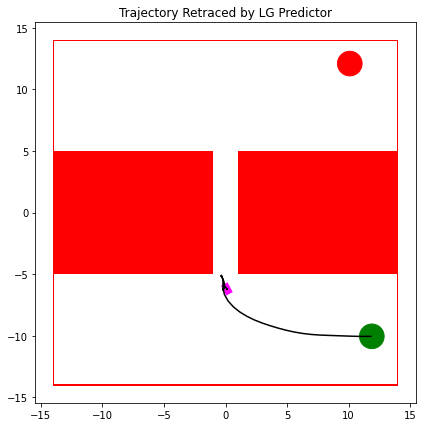

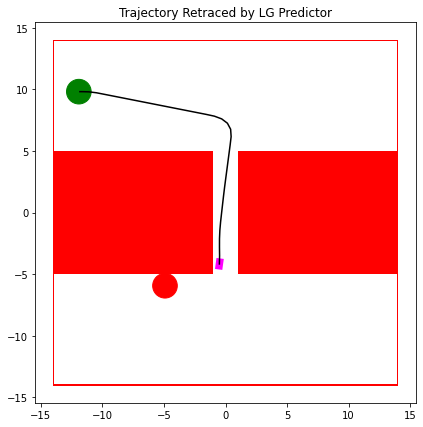

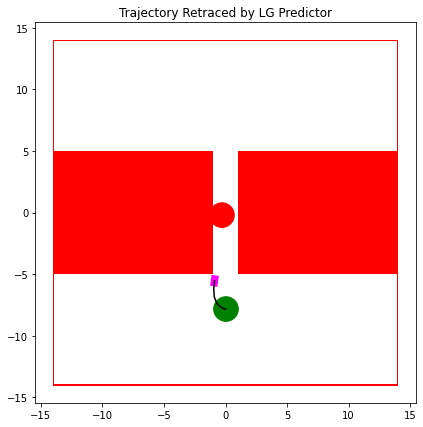

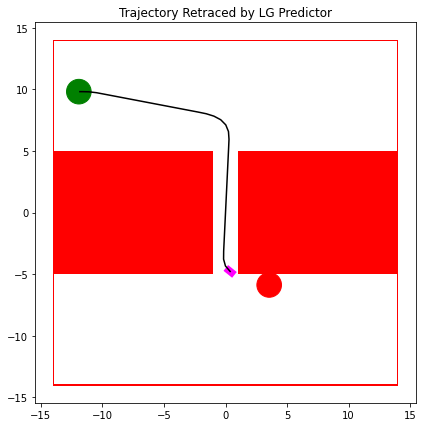

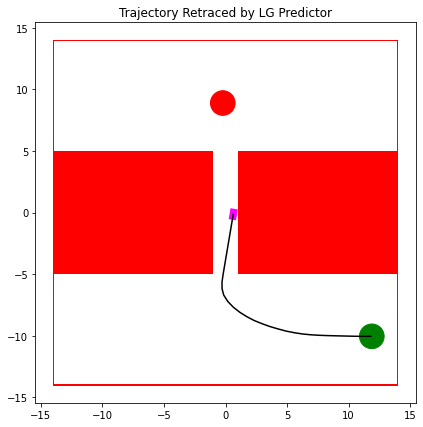

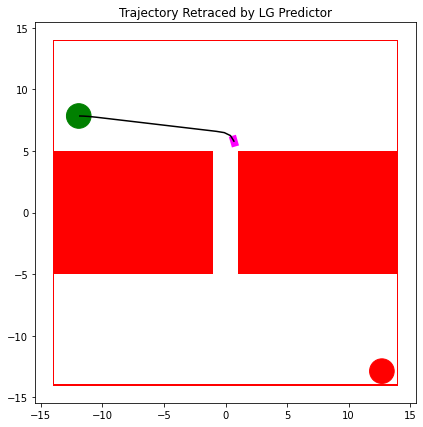

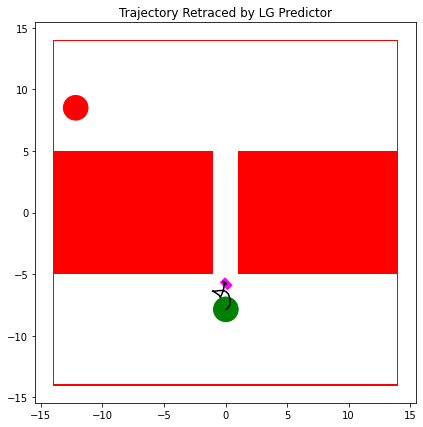

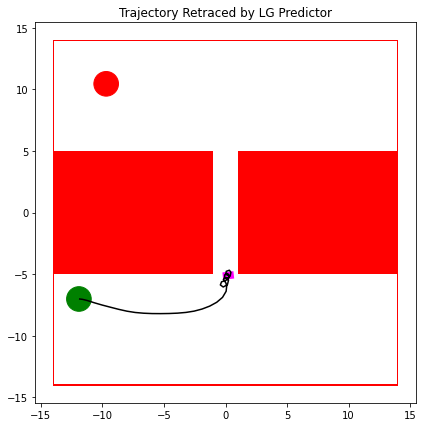

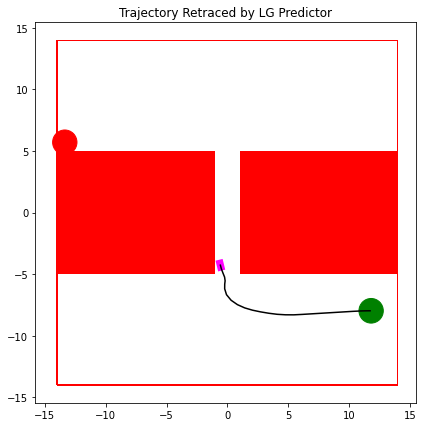

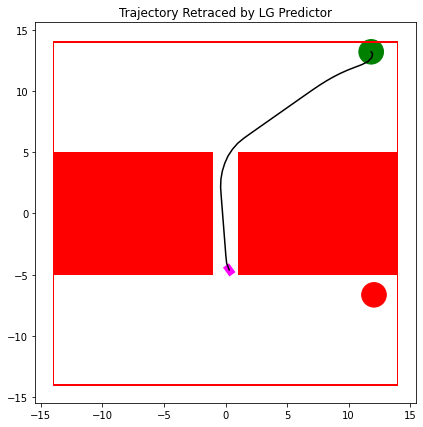

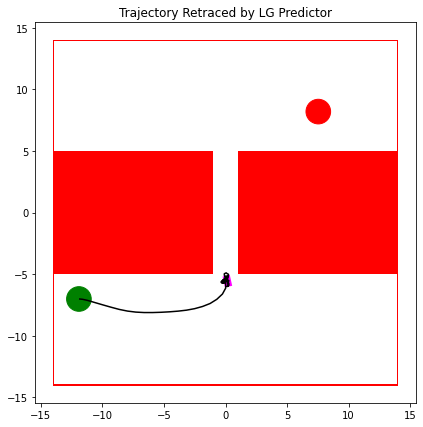

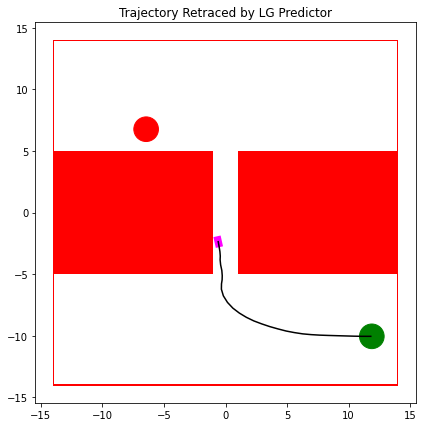

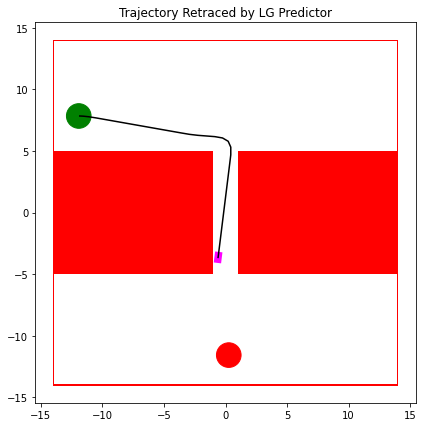

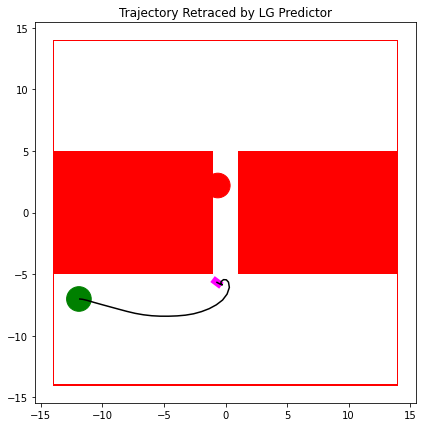

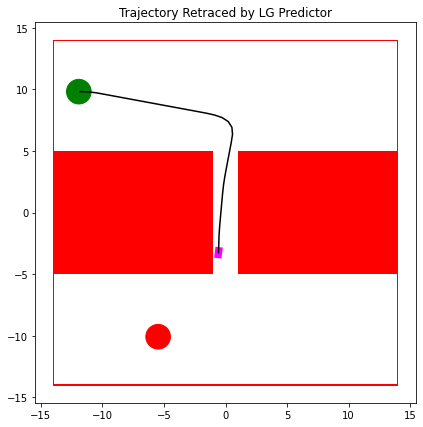

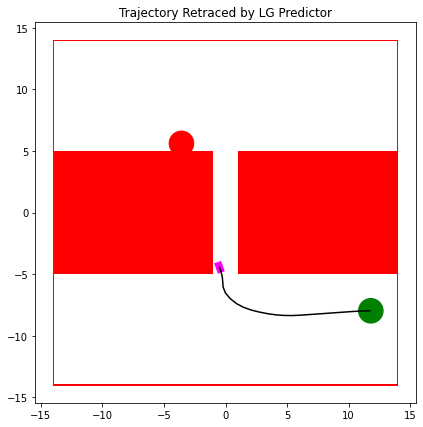

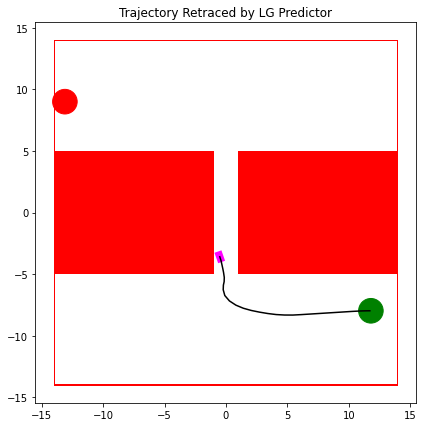

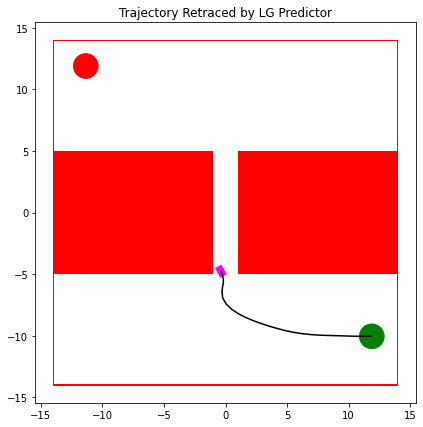

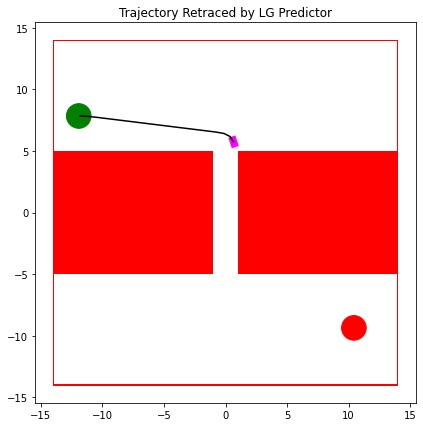

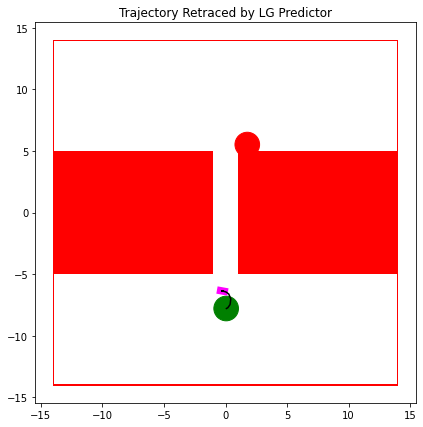

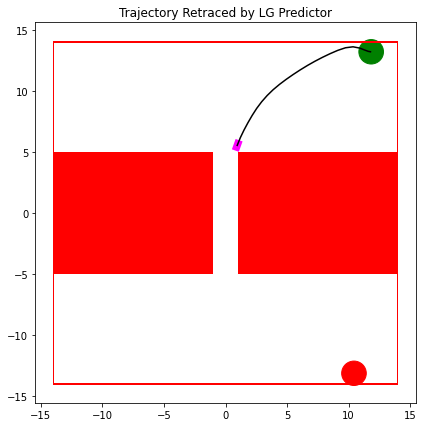

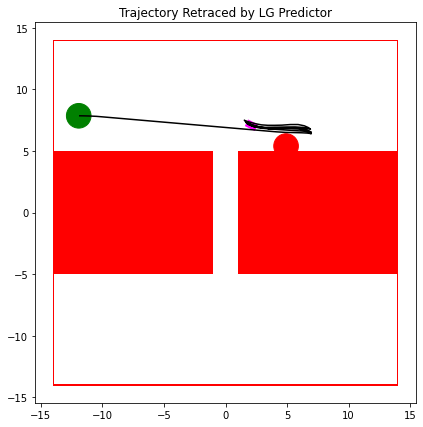

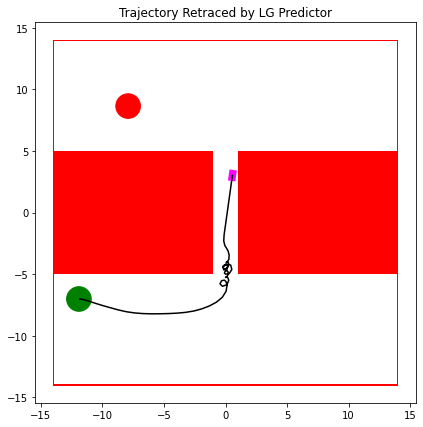

In [ ]:
plt.rcParams['figure.figsize'] = [15,7]
tot = 0
for info in random.sample(data['train'], 100):
    old_traj = info[0]
    
    try:
        start = old_traj[0]
        goal1 = old_traj[-1]
    except:
        tot += 1
        continue

    goal = goal1
    traj, success, goal_ = check_model(dnn.to('cuda'), reachable_model.to('cuda'), env, start, goal1)
    # 
    start = start
    # print(success)
    if not success:
        # plt.subplot(1, 2, 1)
        # plt.title('Trajectory in Train Dataset')
        # start_region = plt.Circle(((start[0]),(start[1])),1,color='green')
        # plt.gca().add_patch(start_region)

        # start_region = plt.Circle(((goal[0]),(goal[1])),1,color='red')
        # plt.gca().add_patch(start_region)
        # env.plot_traj(old_traj)
        # plt.show()
        plt.subplot(1, 2, 1)
        plt.title('Trajectory Retraced by LG Predictor')
        start_region = plt.Circle(((start[0]),(start[1])),1,color='green')
        plt.gca().add_patch(start_region)

        start_region = plt.Circle(((goal_[0]),(goal_[1])),1,color='red')
        plt.gca().add_patch(start_region)
        env.plot_traj(traj)
        plt.show()
    if success: tot+=1
    # input()

In [ ]:
tot

60

In [ ]:
plt.rcParams['figure.figsize'] = [15,7]
tot = 0
for info in random.sample(data['train'], 100):
    old_traj = info[0]
    

    start = old_traj[0]
    goal1 = old_traj[-1]

    goal = goal1
    traj, success, goal_ = check_model(dnn.to('cuda'), env, start, goal1)
    # 
    # print(success)
    if not success or 1:
        plt.subplot(1, 2, 1)
        plt.title('Trajectory in Train Dataset')
        start_region = plt.Circle(((start[0]),(start[1])),1,color='green')
        plt.gca().add_patch(start_region)

        start_region = plt.Circle(((goal[0]),(goal[1])),1,color='red')
        plt.gca().add_patch(start_region)
        env.plot_traj(old_traj)
        # plt.show()
        plt.subplot(1, 2, 2)
        plt.title('Trajectory Retraced by LG Predictor')
        start_region = plt.Circle(((start[0]),(start[1])),1,color='green')
        plt.gca().add_patch(start_region)

        start_region = plt.Circle(((goal_[0]),(goal_[1])),1,color='red')
        plt.gca().add_patch(start_region)
        try:
            env.plot_traj(traj)
        except:pass
        plt.show()
    if success: tot+=1
    # input()

AttributeError: ignored

In [ ]:
results_dict = {}
train_success, test_success  = [0], [0]
dim_in, dim_out = 8, 3
num_components = 2
hidden_size = 100
best_param, best_success = None, None
for num_components in range(1, 11):
    for hidden_size in [100]:
        for lr in [1e-3]:
            mdn = MixtureDensityNetwork(dim_in, dim_out, num_components, hidden_size = hidden_size).to(device)
            mdn = train_mdn(mdn.to(device), train=train_lg_data.DataLoader, epochs=20, lr=lr)
            success_rate = evaluate(mdn, env, train=True)
            results_dict[(num_components, hidden_size, lr)] = success_rate
            if best_success is None or success_rate > best_success:
                best_success = success_rate
                best_param = (num_components, hidden_size, lr)

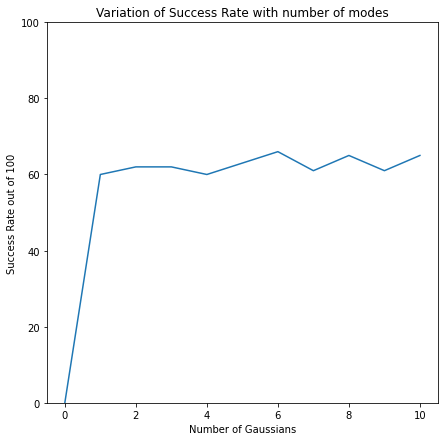

In [ ]:
suc = [0]*11
for k, v in results_dict.items():
    suc[k[0]] = v
plt.plot(suc)
plt.ylim(0, 100)
plt.ylabel('Success Rate out of 100')
plt.xlabel('Number of Gaussians')
plt.title('Variation of Success Rate with number of modes')
plt.show()